In [1]:
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np
import statistics
import math
import seaborn as sns
from scipy import stats
import statsmodels.api as sm
import pandas as pd
import matplotlib as mpl
from sklearn.cluster import KMeans
#import dofitPython_functions as LogFit 
from scipy.stats import normaltest
from scipy.stats import kruskal
from scipy.stats import shapiro

In [2]:
ECearth_ds = xr.open_dataset('/share/pech2273/ECEarthProcessed.nc')
NorESM_ds = xr.open_dataset('/share/pech2273/NorESMProcessed.nc')
ECMassFrac_ds = xr.open_dataset("/share/pech2273/ECMassFrac.nc")
NorMassFrac_ds = xr.open_dataset("/share/pech2273/NorMassFrac.nc")
ECMassFrac_ds = ECMassFrac_ds.reindex(time = ECearth_ds['time'])
ECMassFracGroups = ECMassFrac_ds.groupby(ECearth_ds['label'])
NorMassFracGroups = NorMassFrac_ds.groupby(NorESM_ds['label'])
ECearthGroups = ECearth_ds.groupby(ECearth_ds['label'])
NorGroups = NorESM_ds.groupby(NorESM_ds['label'])

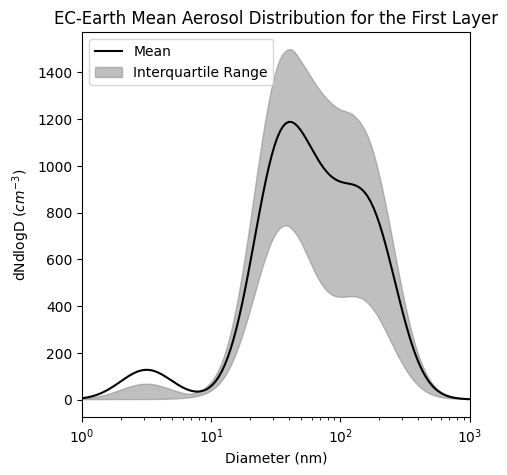

In [3]:
plt.figure(figsize =(5,5))

(ECearth_ds['Tot_dis']*1E-6).isel(lev = 0).mean('time').plot(xscale = 'log', xlim = [1,1000], label = 'Mean', color = 'black')


plt.fill_between(ECearth_ds['D'],(ECearth_ds['Tot_dis']*1E-6).isel(lev = 0).quantile(0.75, dim='time'),(ECearth_ds['Tot_dis']*1E-6).isel(lev = 0).quantile(0.25, dim='time'),color='gray', alpha=0.5, label = 'Interquartile Range')
plt.xlabel('Diameter (nm)')
plt.ylabel('dNdlogD ($cm^{-3}$)')
plt.title('EC-Earth Mean Aerosol Distribution for the First Layer')
plt.legend()

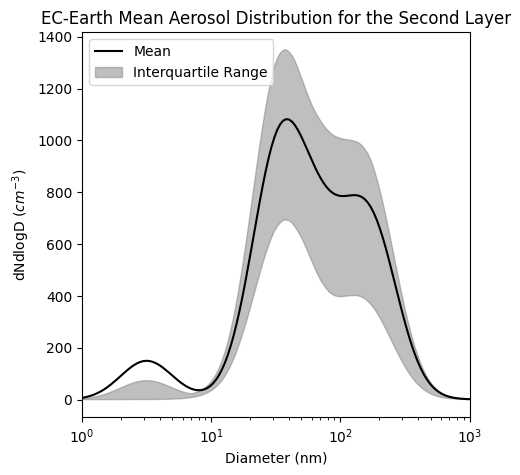

In [4]:
plt.figure(figsize =(5,5))

(ECearth_ds['Tot_dis']*1E-6).isel(lev = 1).mean('time').plot(xscale = 'log', xlim = [1,1000], label = 'Mean', color = 'black')


plt.fill_between(ECearth_ds['D'],(ECearth_ds['Tot_dis']*1E-6).isel(lev = 1).quantile(0.75, dim='time'),(ECearth_ds['Tot_dis']*1E-6).isel(lev = 1).quantile(0.25, dim='time'),color='gray', alpha=0.5, label = 'Interquartile Range')
plt.xlabel('Diameter (nm)')
plt.ylabel('dNdlogD ($cm^{-3}$)')
plt.title('EC-Earth Mean Aerosol Distribution for the Second Layer')
plt.legend()

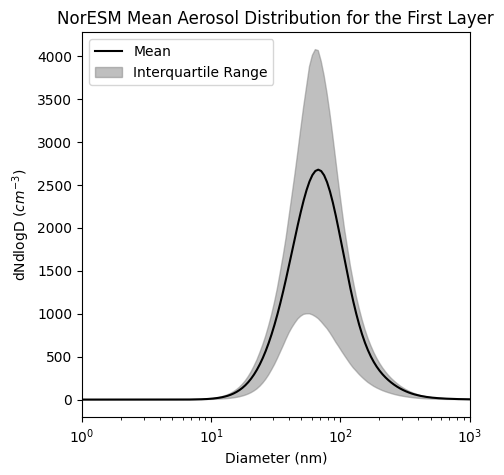

In [5]:
plt.figure(figsize =(5,5))

NorESM_ds['Tot_dis'].isel(lev = -1).mean('time').plot(xscale = 'log', xlim = [1,1000], label = 'Mean', color = 'black')


plt.fill_between(NorESM_ds['D'],NorESM_ds['Tot_dis'].isel(lev = -1).quantile(0.75, dim='time'),NorESM_ds['Tot_dis'].isel(lev = -1).quantile(0.25, dim='time'),color='gray', alpha=0.5, label = 'Interquartile Range')
plt.xlabel('Diameter (nm)')
plt.ylabel('dNdlogD ($cm^{-3}$)')
plt.title('NorESM Mean Aerosol Distribution for the First Layer')
plt.legend()

In [6]:
NorESM_ds['D'].isel(D = NorESM_ds['Tot_dis'].isel(lev = -1).mean('time').argmax())

<xarray.DataArray 'D' ()> Size: 8B
array(67.47544053)
Coordinates:
    station  <U6 24B ...
    D        float64 8B 67.48
    Dx       float64 8B ...
    index    <U19 76B ...
    lev      float64 8B 992.6

In [7]:
16-7.5


8.5

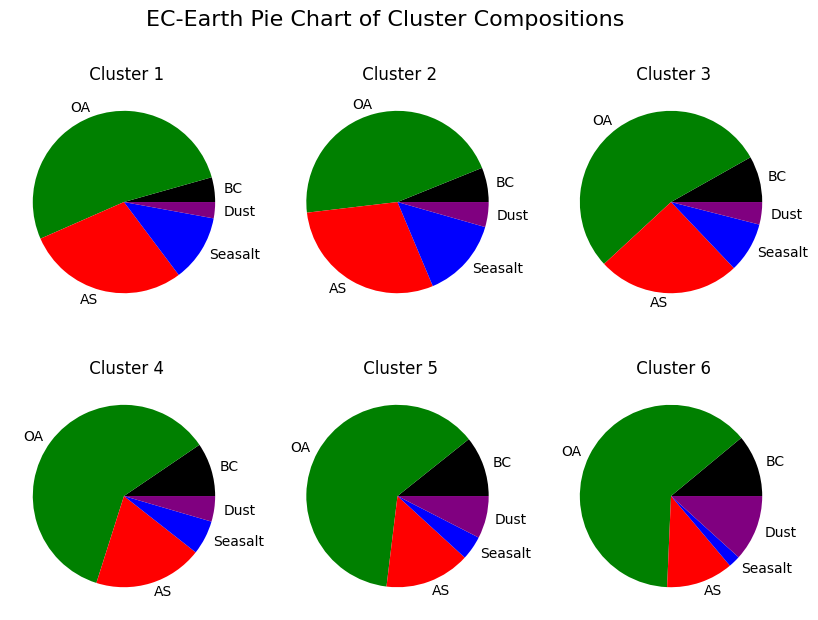

In [8]:
fig = plt.figure(figsize = (10,7))
ECClusters = [5,2,1,3,4,0]

for i in range(1,7):
    plt.subplot(2,3,i)
    plt.title(f' Cluster {i}')
    plt.pie([ECMassFracGroups[ECClusters[i-1]]['BCMassFrac'].dropna('time').isel(lev = 0).mean('time'),\
             ECMassFracGroups[ECClusters[i-1]]['OAMassFrac'].dropna('time').isel(lev = 0).mean('time'),\
             ECMassFracGroups[ECClusters[i-1]]['SO4MassFrac'].dropna('time').isel(lev = 0).mean('time'),\
             ECMassFracGroups[ECClusters[i-1]]['SeasaltMassFrac'].dropna('time').isel(lev = 0).mean('time'),\
             ECMassFracGroups[ECClusters[i-1]]['DustMassFrac'].dropna('time').isel(lev = 0).mean('time')],\
             colors=['black', 'green','red','blue','purple'], labels = ['BC','OA','AS','Seasalt', 'Dust'])
fig.suptitle('EC-Earth Pie Chart of Cluster Compositions', fontsize = 16)

plt.show()

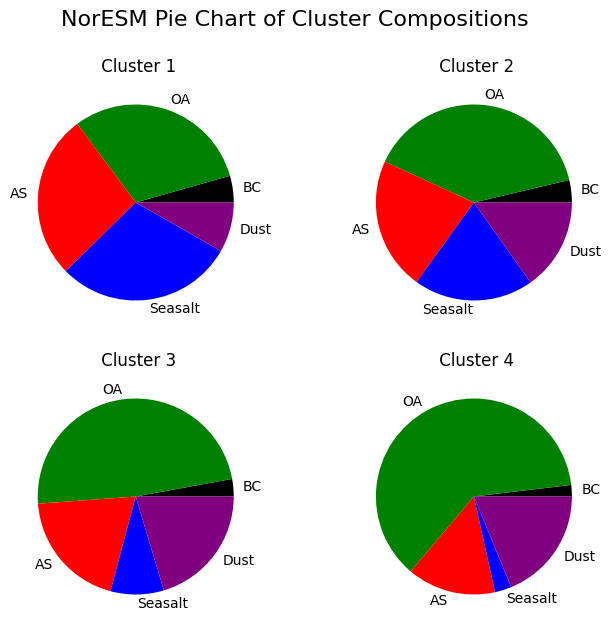

In [9]:
fig = plt.figure(figsize = (8,7))
NorClusters = [3,1,0,2]
for i in range(1,5):
    plt.subplot(2,2,i)
    plt.title(f' Cluster {i}')
    plt.pie([NorMassFracGroups[NorClusters[i-1]]['BCMassFrac'].dropna('time').isel(lev = -1).mean('time'),\
             NorMassFracGroups[NorClusters[i-1]]['OAMassFrac'].dropna('time').isel(lev = -1).mean('time'),\
             NorMassFracGroups[NorClusters[i-1]]['SO4MassFrac'].dropna('time').isel(lev = -1).mean('time'),\
             NorMassFracGroups[NorClusters[i-1]]['SeasaltMassFrac'].dropna('time').isel(lev = -1).mean('time'),\
             NorMassFracGroups[NorClusters[i-1]]['DustMassFrac'].dropna('time').isel(lev = -1).mean('time')],\
             colors=['black', 'green','red','blue','purple'], labels = ['BC','OA','AS','Seasalt', 'Dust'])
fig.suptitle('NorESM Pie Chart of Cluster Compositions', fontsize = 16)

plt.show()

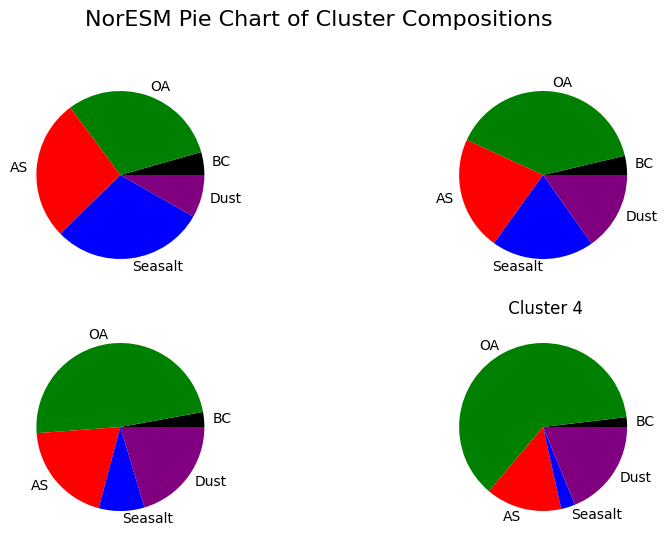

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(10, 6)) 
NorClusters = [3,1,0,2]
for i in range(4):
    ax = axes.flatten()[i]
    

    plt.title(f' Cluster {i+1}')
    ax.pie([NorMassFracGroups[NorClusters[i]]['BCMassFrac'].dropna('time').isel(lev = -1).mean('time'),\
             NorMassFracGroups[NorClusters[i]]['OAMassFrac'].dropna('time').isel(lev = -1).mean('time'),\
             NorMassFracGroups[NorClusters[i]]['SO4MassFrac'].dropna('time').isel(lev = -1).mean('time'),\
             NorMassFracGroups[NorClusters[i]]['SeasaltMassFrac'].dropna('time').isel(lev = -1).mean('time'),\
             NorMassFracGroups[NorClusters[i]]['DustMassFrac'].dropna('time').isel(lev = -1).mean('time')],\
             colors=['black', 'green','red','blue','purple'], labels = ['BC','OA','AS','Seasalt', 'Dust'])
fig.suptitle('NorESM Pie Chart of Cluster Compositions', fontsize = 16)

plt.show()

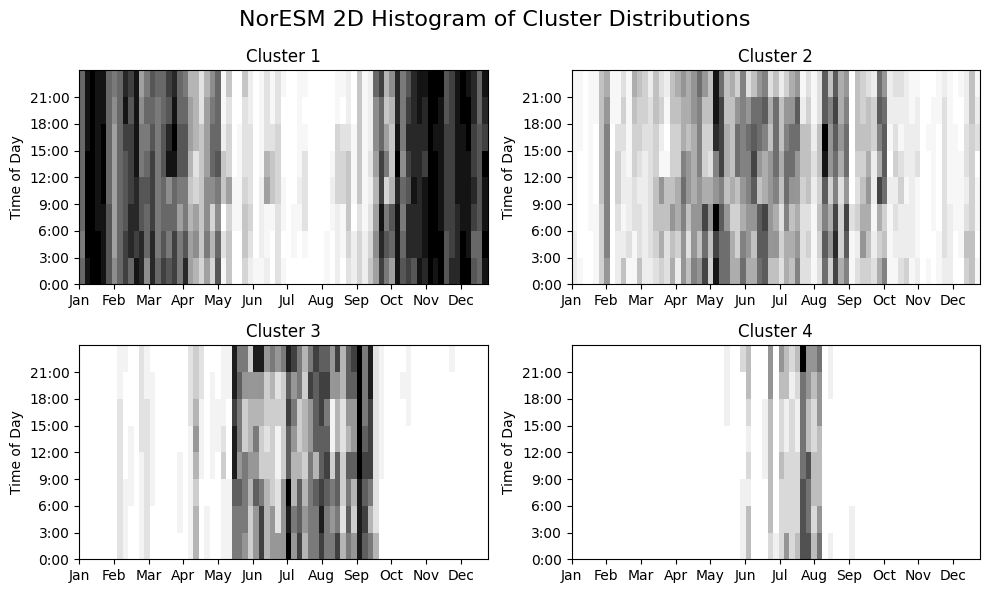

In [11]:
NorESM_ds['time_of_day'] = NorESM_ds['time.hour'] 
NorESM_ds['day_of_year'] = NorESM_ds['time.dayofyear'] 
x_bin_edges = np.linspace(0, 365, 76)
y_bin_edges = np.linspace(0, 24, 9)

fig, axes = plt.subplots(2, 2, figsize=(10, 6)) 
for i in range(4):
    ax = axes.flatten()[i]
    
    ax.hist2d(NorESM_ds['day_of_year'].where(NorESM_ds['label'] ==NorClusters[i], drop = 'true')\
              , NorESM_ds['time_of_day'].where(NorESM_ds['label'] ==NorClusters[i], drop = 'true')\
              , bins = [x_bin_edges,y_bin_edges], density = 'true', cmap = 'Greys')
    ax.set_yticks(np.arange(0, 24, 3)) 
    ax.set_yticklabels([f'{hour}:00' for hour in np.arange(0, 24, 3)])  
    ax.set_xticks(np.arange(0, 365, 31))  
    ax.set_xticklabels(['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']) 
    ax.set_ylabel('Time of Day')
    ax.set_title(f'Cluster {i+1}', fontsize = 12) 
fig.suptitle('NorESM 2D Histogram of Cluster Distributions', fontsize = 16)
plt.tight_layout()
plt.show()

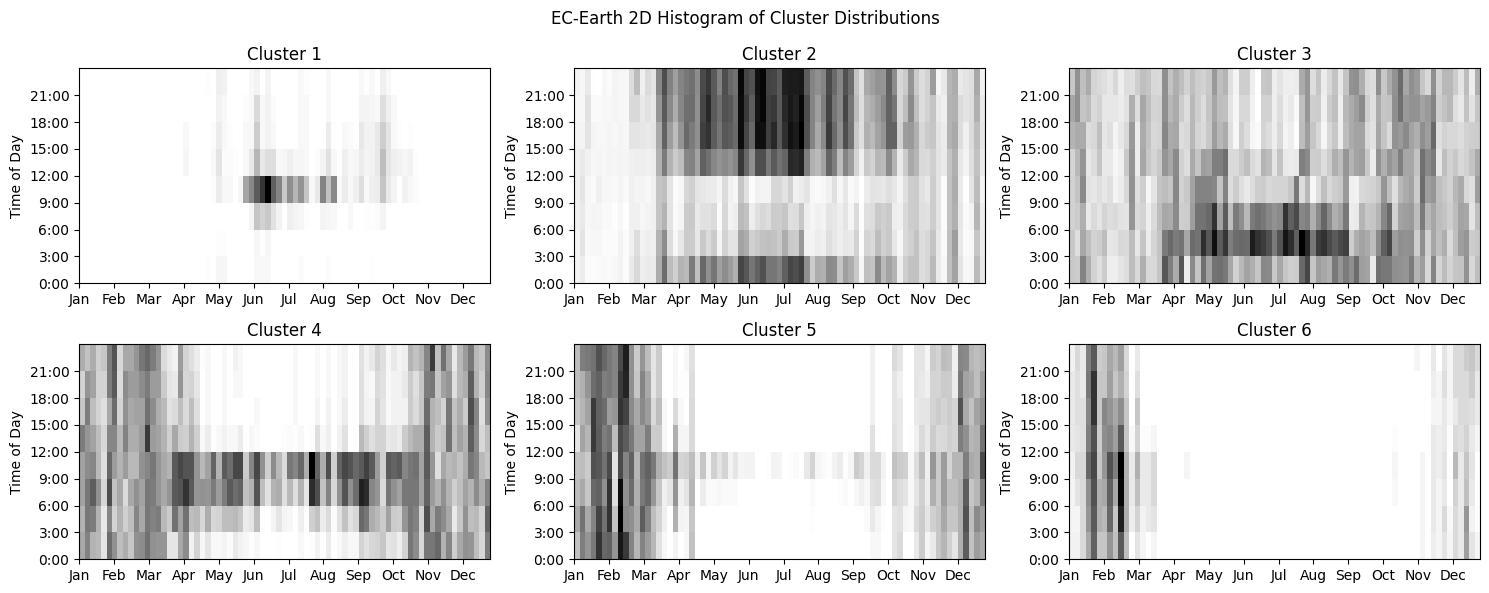

In [12]:
ECearth_ds['time_of_day'] = ECearth_ds['time.hour'] 
ECearth_ds['day_of_year'] = ECearth_ds['time.dayofyear'] 
x_bin_edges = np.linspace(0, 365, 76)
y_bin_edges = np.linspace(0, 24, 9)

fig, axes = plt.subplots(2, 3, figsize=(15, 6)) 
for i in range(6):
    ax = axes.flatten()[i]
    
    ax.hist2d(ECearth_ds['day_of_year'].where(ECearth_ds['label'] ==ECClusters[i], drop = 'true'),\
              ECearth_ds['time_of_day'].where(ECearth_ds['label'] ==ECClusters[i], drop = 'true'),\
              bins = [x_bin_edges,y_bin_edges], density = 'true', cmap = 'Greys')
    ax.set_yticks(np.arange(0, 24, 3)) 
    ax.set_yticklabels([f'{hour}:00' for hour in np.arange(0, 24, 3)])  
    ax.set_xticks(np.arange(0, 365, 31))  
    ax.set_xticklabels(['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']) 
    ax.set_ylabel('Time of Day')
    ax.set_title(f'Cluster {i+1}') 
fig.suptitle('EC-Earth 2D Histogram of Cluster Distributions')

plt.tight_layout()
plt.show()

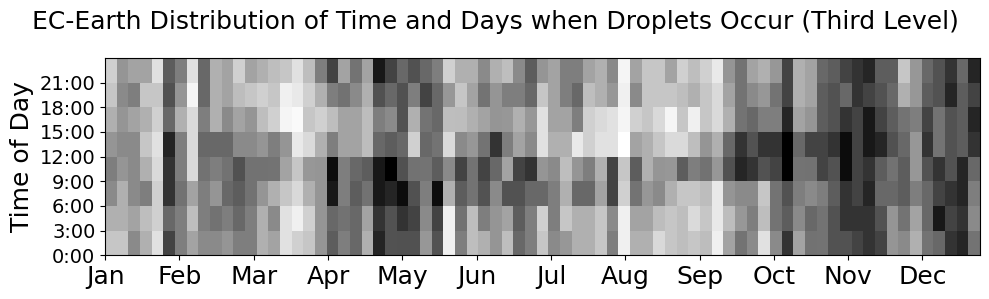

In [13]:

x_bin_edges = np.linspace(0, 365, 76)
y_bin_edges = np.linspace(0, 24, 9)

fig, ax = plt.subplots(1, 1, figsize=(10, 3)) 
ax.hist2d(ECearth_ds['day_of_year'].where(ECearth_ds['Droplets'].isel(lev = 2)>0, drop = 'true')\
          , ECearth_ds['time_of_day'].where(ECearth_ds['Droplets'].isel(lev = 2)>0, drop = 'true')\
          , bins = [x_bin_edges,y_bin_edges], density = True, cmap = 'Greys')
ax.set_yticks(np.arange(0, 24, 3)) 
ax.set_yticklabels([f'{hour}:00' for hour in np.arange(0, 24, 3)], fontsize = 14)  
ax.set_xticks(np.arange(0, 365, 31))  
ax.set_xticklabels(['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'] , fontsize = 18) 
ax.set_ylabel('Time of Day', fontsize = 18)
fig.suptitle('EC-Earth Distribution of Time and Days when Droplets Occur (Third Level)', fontsize = 18)

plt.tight_layout()
plt.show()

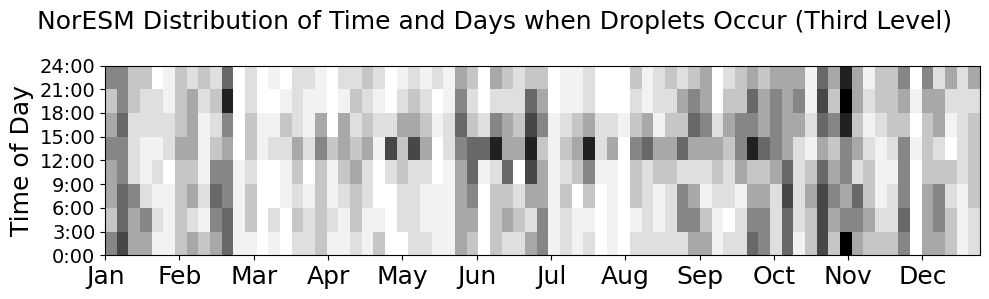

In [14]:

x_bin_edges = np.linspace(0, 365, 76)
y_bin_edges = np.linspace(0, 24, 9)

fig, ax = plt.subplots(1, 1, figsize=(10, 3)) 
ax.hist2d(NorESM_ds['day_of_year'].where(NorESM_ds['Droplets'].isel(lev = -8)>0, drop = 'true'), NorESM_ds['time_of_day'].where(NorESM_ds['Droplets'].isel(lev = -8)>0, drop = 'true')\
          , bins = [x_bin_edges,y_bin_edges], density = True, cmap = 'Greys')
ax.set_yticks(np.arange(0, 27, 3)) 
ax.set_yticklabels([f'{hour}:00' for hour in np.arange(0, 27, 3)], fontsize = 14)  
ax.set_xticks(np.arange(0, 365, 31))  
ax.set_xticklabels(['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'], fontsize = 18) 
ax.set_ylabel('Time of Day', fontsize = 18)
fig.suptitle('NorESM Distribution of Time and Days when Droplets Occur (Third Level)', fontsize = 18)

plt.tight_layout()
plt.show()

In [15]:
print(np.arange(0, 27, 3))

[ 0  3  6  9 12 15 18 21 24]


In [16]:
np.linspace(0, 24, 9)


array([ 0.,  3.,  6.,  9., 12., 15., 18., 21., 24.])

(1000.0, 0.0)

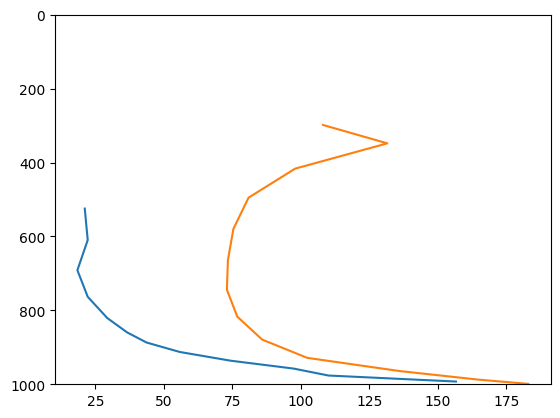

In [17]:
plt.plot(NorESM_ds['Droplets'].median('time'),NorESM_ds['lev'] )
plt.plot(ECearth_ds['Droplets'].median('time'),ECearth_ds['lev'] )

plt.ylim(1000,0)

(1000, 1)

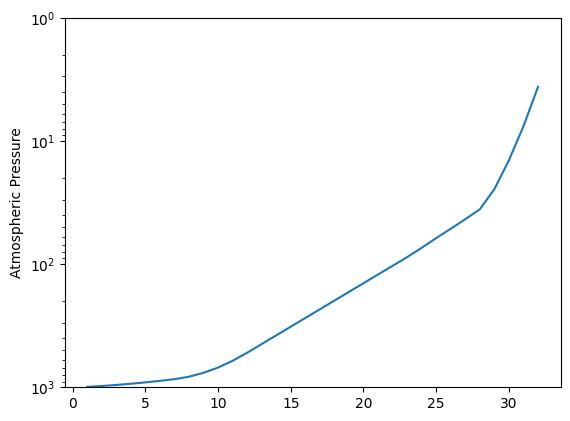

In [18]:
plt.plot( range(32,0,-1),(NorESM_ds['lev']))
plt.ylabel('Atmospheric Pressure')
plt.yscale('log')
plt.ylim(1000,1)

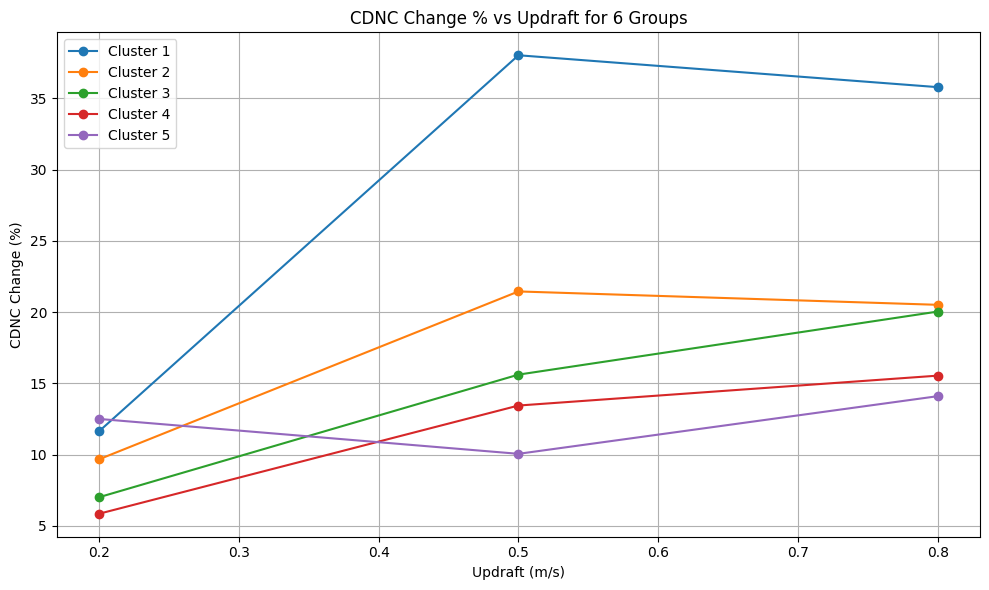

In [19]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Data extracted from the user-provided list
data = {
    'Updraft': [0.2]*5 + [0.5]*5 + [0.8]*5,
    'CDNC Change %': [11.62, 9.66, 7.00, 5.84, 12.50,
                      38.03, 21.45, 15.61, 13.44, 10.05,
                      35.79, 20.51, 20.04, 15.54, 14.10]
}

df = pd.DataFrame(data)

# Pivot the data to group by series (group 1 to 6)
grouped = df.groupby(df.index % 5)  # 6 groups

# Plotting
plt.figure(figsize=(10, 6))
for i, (name, group) in enumerate(grouped):
    plt.plot([0.2, 0.5, 0.8], group['CDNC Change %'].values, marker='o', label=f'Cluster {i+1}')

plt.xlabel('Updraft (m/s)')
plt.ylabel('CDNC Change (%)')
plt.title('CDNC Change % vs Updraft for 6 Groups')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


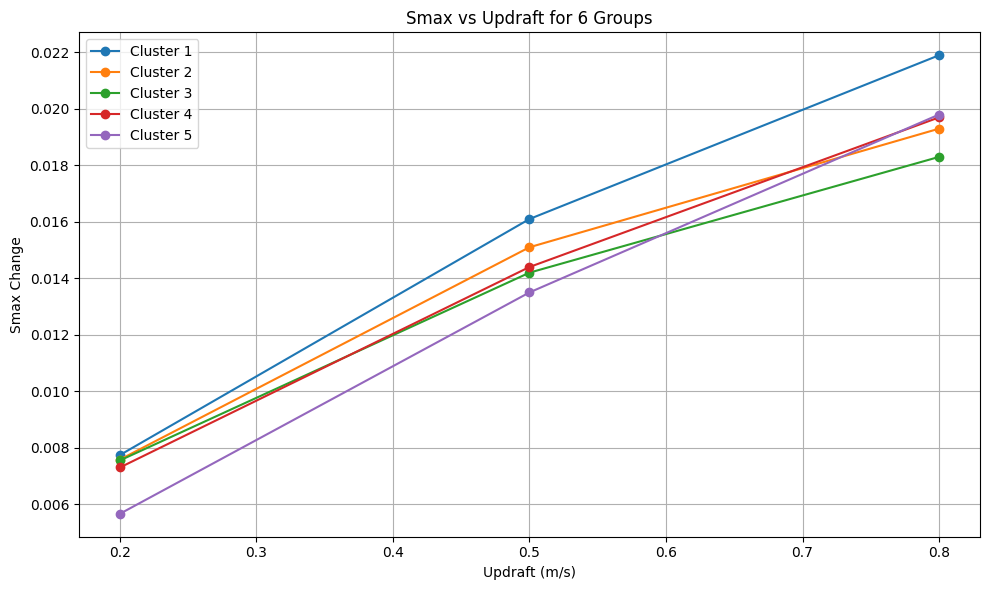

In [20]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Data extracted from the user-provided list

dataSmaxEC = {
    'Updraft': [0.2]*5 + [0.5]*5 + [0.8]*5,
    'Smax Change': [0.00774,0.00758,0.00755,0.00730,0.00566,
                    0.0161,0.0151,0.0142,0.0144,0.0135,
                    0.0219,0.0193,0.0183,0.0197,0.0198]
}

df = pd.DataFrame(dataSmaxEC)

# Pivot the data to group by series (group 1 to 6)
grouped = df.groupby(df.index % 5)  # 6 groups

# Plotting
plt.figure(figsize=(10, 6))
for i, (name, group) in enumerate(grouped):
    plt.plot([0.2, 0.5, 0.8], group['Smax Change'].values, marker='o', label=f'Cluster {i+1}')

plt.xlabel('Updraft (m/s)')
plt.ylabel('Smax Change')
plt.title('Smax vs Updraft for 6 Groups')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


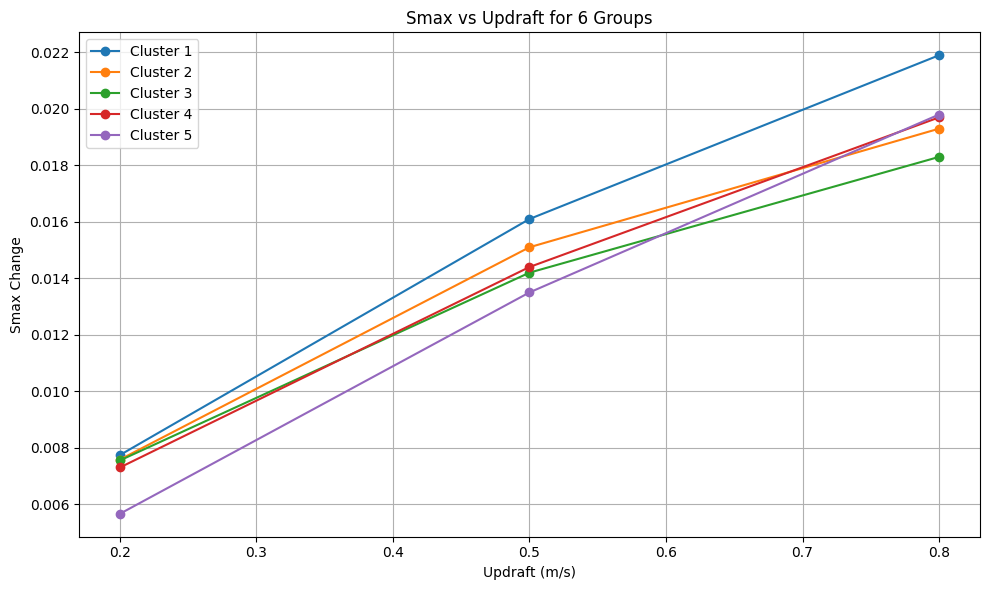

In [21]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Data extracted from the user-provided list

dataSmaxEC = {
    'Updraft': [0.2]*5 + [0.5]*5 + [0.8]*5,
    'Smax Change': [0.00774,0.00758,0.00755,0.00730,0.00566,
                    0.0161,0.0151,0.0142,0.0144,0.0135,
                    0.0219,0.0193,0.0183,0.0197,0.0198]
}

df = pd.DataFrame(dataSmaxEC)

# Pivot the data to group by series (group 1 to 6)
grouped = df.groupby(df.index % 5)  # 6 groups

# Plotting
plt.figure(figsize=(10, 6))
for i, (name, group) in enumerate(grouped):
    plt.plot([0.2, 0.5, 0.8], group['Smax Change'].values, marker='o', label=f'Cluster {i+1}')

plt.xlabel('Updraft (m/s)')
plt.ylabel('Smax Change')
plt.title('Smax vs Updraft for 6 Groups')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


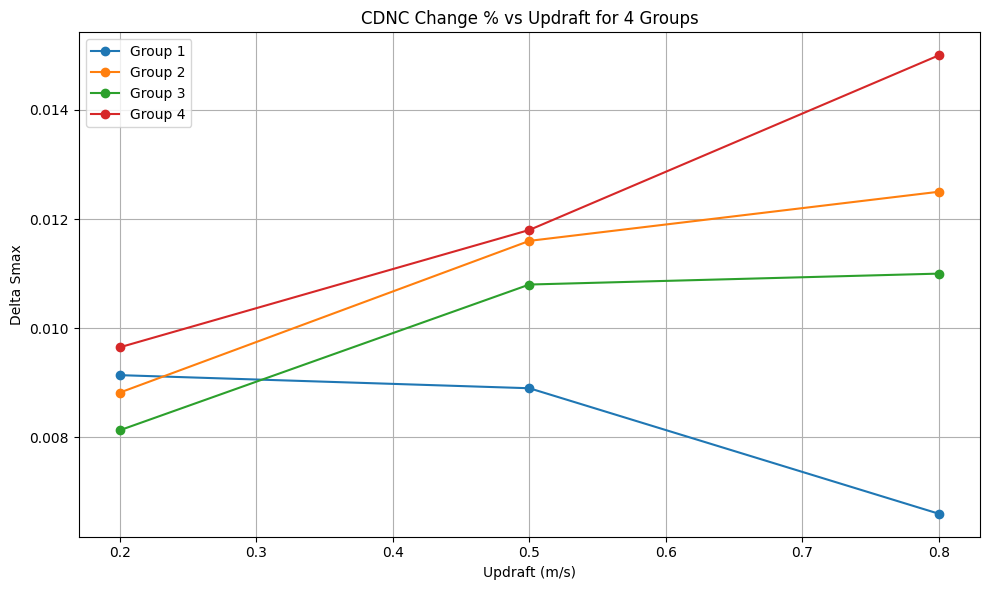

In [22]:
# New data extracted from the second image
data2 = {
    'Updraft': [0.2]*4 + [0.5]*4 + [0.8]*4,
    'Smax Change': [0.00914,0.00882,0.00813,0.00965,0.0089,0.0116,0.0108,0.0118,0.0066,0.0125,0.0110,0.0150]
}

df2 = pd.DataFrame(data2)

# Grouping by the index mod the number of updraft steps (4 groups this time)
grouped2 = df2.groupby(df2.index % 4)

# Plotting
plt.figure(figsize=(10, 6))
for i, (name, group) in enumerate(grouped2):
    plt.plot([0.2, 0.5, 0.8], group['Smax Change'].values, marker='o', label=f'Group {i+1}')

plt.xlabel('Updraft (m/s)')
plt.ylabel('Delta Smax')
plt.title('CDNC Change % vs Updraft for 4 Groups')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


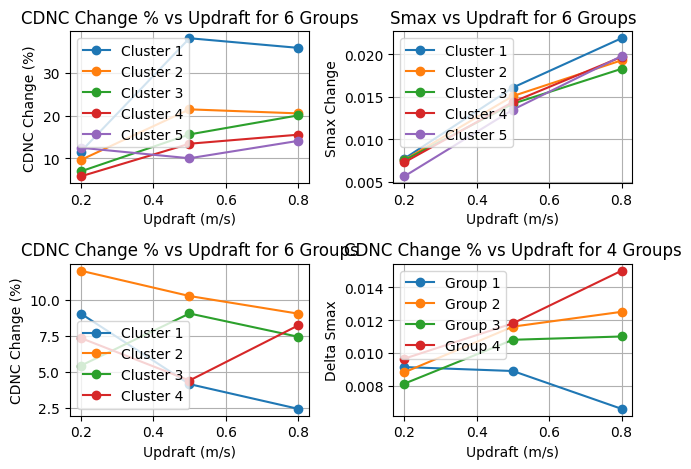

In [23]:
# Data extracted from the user-provided list
data = {
    'Updraft': [0.2]*5 + [0.5]*5 + [0.8]*5,
    'CDNC Change %': [11.62, 9.66, 7.00, 5.84, 12.50,
                      38.03, 21.45, 15.61, 13.44, 10.05,
                      35.79, 20.51, 20.04, 15.54, 14.10]
}

df = pd.DataFrame(data)

# Pivot the data to group by series (group 1 to 6)
grouped = df.groupby(df.index % 5)  # 6 groups
plt.subplot(2,2,1)
# Plotting

for i, (name, group) in enumerate(grouped):
    plt.plot([0.2, 0.5, 0.8], group['CDNC Change %'].values, marker='o', label=f'Cluster {i+1}')

plt.xlabel('Updraft (m/s)')
plt.ylabel('CDNC Change (%)')
plt.title('CDNC Change % vs Updraft for 6 Groups')
plt.legend()
plt.grid(True)

dataSmaxEC = {
    'Updraft': [0.2]*5 + [0.5]*5 + [0.8]*5,
    'Smax Change': [0.00774,0.00758,0.00755,0.00730,0.00566,
                    0.0161,0.0151,0.0142,0.0144,0.0135,
                    0.0219,0.0193,0.0183,0.0197,0.0198]
}

df = pd.DataFrame(dataSmaxEC)

# Pivot the data to group by series (group 1 to 6)
grouped = df.groupby(df.index % 5)  # 6 groups

# Plotting
plt.subplot(2,2,2)

for i, (name, group) in enumerate(grouped):
    plt.plot([0.2, 0.5, 0.8], group['Smax Change'].values, marker='o', label=f'Cluster {i+1}')

plt.xlabel('Updraft (m/s)')
plt.ylabel('Smax Change')
plt.title('Smax vs Updraft for 6 Groups')
plt.legend()
plt.grid(True)

data = {
    'Updraft': [0.2]*4 + [0.5]*4 + [0.8]*4,
    'CDNC Change %': [9.03,12.0,5.43,7.34,4.15,10.25,9.04,4.40,2.44,9.03,7.43,8.21]
}

df = pd.DataFrame(data)

# Pivot the data to group by series (group 1 to 6)
grouped = df.groupby(df.index % 4)  # 6 groups

# Plotting
plt.subplot(2,2,3)

for i, (name, group) in enumerate(grouped):
    plt.plot([0.2, 0.5, 0.8], group['CDNC Change %'].values, marker='o', label=f'Cluster {i+1}')

plt.xlabel('Updraft (m/s)')
plt.ylabel('CDNC Change (%)')
plt.title('CDNC Change % vs Updraft for 6 Groups')
plt.legend()
plt.grid(True)

data2 = {
    'Updraft': [0.2]*4 + [0.5]*4 + [0.8]*4,
    'Smax Change': [0.00914,0.00882,0.00813,0.00965,0.0089,0.0116,0.0108,0.0118,0.0066,0.0125,0.0110,0.0150]
}

df2 = pd.DataFrame(data2)

# Grouping by the index mod the number of updraft steps (4 groups this time)
grouped2 = df2.groupby(df2.index % 4)

# Plotting
plt.subplot(2,2,4)
for i, (name, group) in enumerate(grouped2):
    plt.plot([0.2, 0.5, 0.8], group['Smax Change'].values, marker='o', label=f'Group {i+1}')

plt.xlabel('Updraft (m/s)')
plt.ylabel('Delta Smax')
plt.title('CDNC Change % vs Updraft for 4 Groups')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


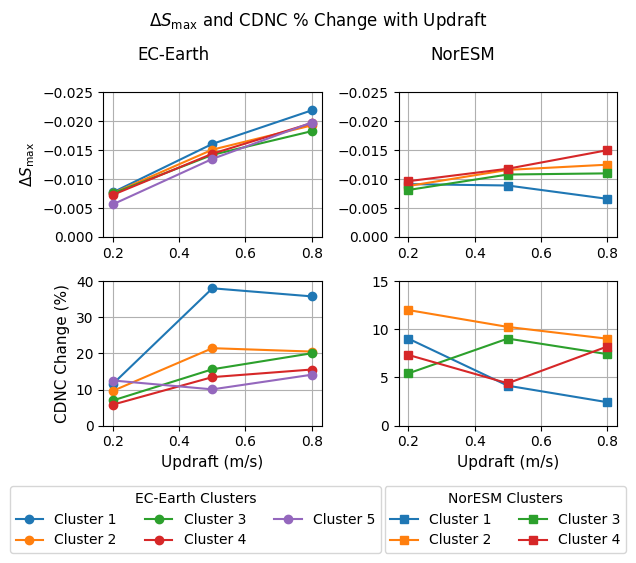

In [24]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import matplotlib.cm as cm
from matplotlib.lines import Line2D

fig, axs = plt.subplots(2, 2, figsize=(6.3, 5))

# --- Plot 1 ---
data1 = {'Updraft': [0.2]*5 + [0.5]*5 + [0.8]*5,
         'CDNC Change %': [11.62, 9.66, 7.00, 5.84, 12.50,
                      38.03, 21.45, 15.61, 13.44, 10.05,
                      35.79, 20.51, 20.04, 15.54, 14.10]
        } 
df1 = pd.DataFrame(data1)
grouped1 = df1.groupby(df1.index % 5)
for i, (_, group) in enumerate(grouped1):
    axs[1, 0].plot([0.2, 0.5, 0.8], group['CDNC Change %'].values, marker='o')
axs[1, 0].set_ylabel('CDNC Change (%)', fontsize = 11)
axs[1, 0].grid(True)
# --- Plot 2 ---
data2 = {
    'Updraft': [0.2]*4 + [0.5]*4 + [0.8]*4,
    'CDNC Change %': [9.03,12.0,5.43,7.34,4.15,10.25,9.04,4.40,2.44,9.03,7.43,8.21]
}  
df2 = pd.DataFrame(data2)
grouped2 = df2.groupby(df2.index % 4)
for i, (_, group) in enumerate(grouped2):
    axs[1, 1].plot([0.2, 0.5, 0.8], group['CDNC Change %'].values, marker='s')
axs[1, 1].grid(True)

# --- Plot 3 ---
data3 = {'Updraft': [0.2]*5 + [0.5]*5 + [0.8]*5,
         'Smax Change': [-0.00774,-0.00758,-0.00755,-0.00730,-0.00566,-0.0161,-0.0151,-0.0142,-0.0144,-0.0135,-0.0219,-0.0193,-0.0183,-0.0197,-0.0198]
}
df3 = pd.DataFrame(data3)
grouped3 = df3.groupby(df3.index % 5)
for i, (_, group) in enumerate(grouped3):
    axs[0, 0].plot([0.2, 0.5, 0.8], group['Smax Change'].values, marker='o')
axs[0, 0].set_ylabel(r'$\Delta S_{\mathrm{max}}$', fontsize = 11)
axs[1, 0].set_xlabel('Updraft (m/s)',fontsize = 11)

axs[0, 0].grid(True)
# --- Plot 4 ---
data4 = {
    'Updraft': [0.2]*4 + [0.5]*4 + [0.8]*4,
    'Smax Change': [-0.00914,-0.00882,-0.00813,-0.00965,-0.0089,-0.0116,-0.0108,-0.0118,-0.0066,-0.0125,-0.0110,-0.0150]
}
df4 = pd.DataFrame(data4)
grouped4 = df4.groupby(df4.index % 4)
for i, (_, group) in enumerate(grouped4):
    axs[0, 1].plot([0.2, 0.5, 0.8], group['Smax Change'].values, marker='s')
axs[1, 1].set_xlabel('Updraft (m/s)', fontsize = 11)
axs[0, 0].set_ylim([0,-0.025])
axs[0, 1].set_ylim([0,-0.025])
axs[1, 0].set_ylim([0,40])
axs[1, 1].set_ylim([0,15])

axs[0, 1].grid(True)


plt.tight_layout()
plt.suptitle(r'$\Delta S_{\mathrm{max}}$ and CDNC % Change with Updraft', fontsize=12, y=1.00)
fig.text(0.27, .9, 'EC-Earth', ha='center', fontsize=12)
fig.text(0.73, .9, 'NorESM', ha='center', fontsize=12)
# Define consistent color maps
colors_cdnc = cm.tab10(range(6))  # For EC-Earth (6 clusters)
colors_smax = cm.tab10(range(4))  # For NorESM (4 clusters)

# Custom legend handles
cdnc_legend_handles = [Line2D([0], [0], color=colors_cdnc[i], marker='o', label=f'Cluster {i+1}', linestyle='-') for i in range(5)]
smax_legend_handles = [Line2D([0], [0], color=colors_smax[i], marker='s', label=f'Cluster {i+1}', linestyle='-') for i in range(4)]

# Place EC-Earth legend under column 1
fig.legend(handles=cdnc_legend_handles, loc='lower left', bbox_to_anchor=(0.00, -0.1), ncol=3, title="EC-Earth Clusters")

# Place NorESM legend under column 2
fig.legend(handles=smax_legend_handles, loc='lower right', bbox_to_anchor=(1, -0.1), ncol=2, title="NorESM Clusters")

# Adjust layout to make room for legends
plt.tight_layout(rect=[0, 0.050, 1, 0.95])
plt.show()


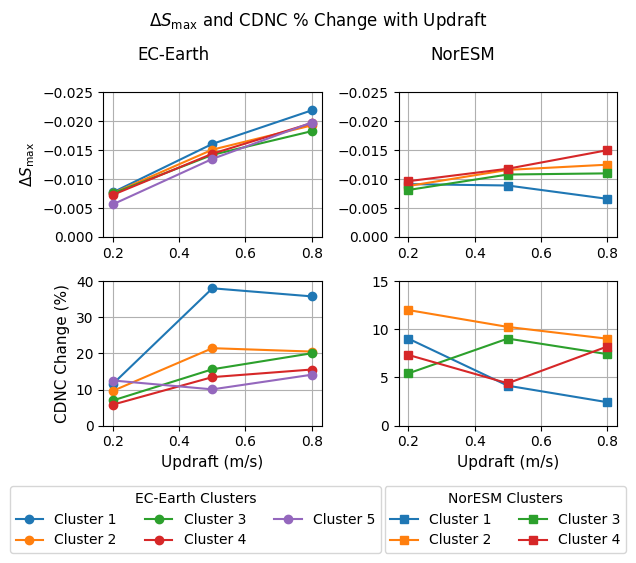

In [24]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import matplotlib.cm as cm
from matplotlib.lines import Line2D

fig, axs = plt.subplots(2, 2, figsize=(6.3, 5))

# --- Plot 1 ---
data1 = {'Updraft': [0.2]*5 + [0.5]*5 + [0.8]*5,
         'CDNC Change %': [11.62, 9.66, 7.00, 5.84, 12.50,
                      38.03, 21.45, 15.61, 13.44, 10.05,
                      35.79, 20.51, 20.04, 15.54, 14.10]
        } 
df1 = pd.DataFrame(data1)
grouped1 = df1.groupby(df1.index % 5)
for i, (_, group) in enumerate(grouped1):
    axs[1, 0].plot([0.2, 0.5, 0.8], group['CDNC Change %'].values, marker='o')
axs[1, 0].set_ylabel('CDNC Change (%)', fontsize = 11)
axs[1, 0].grid(True)
# --- Plot 2 ---
data2 = {
    'Updraft': [0.2]*4 + [0.5]*4 + [0.8]*4,
    'CDNC Change %': [9.03,12.0,5.43,7.34,4.15,10.25,9.04,4.40,2.44,9.03,7.43,8.21]
}  
df2 = pd.DataFrame(data2)
grouped2 = df2.groupby(df2.index % 4)
for i, (_, group) in enumerate(grouped2):
    axs[1, 1].plot([0.2, 0.5, 0.8], group['CDNC Change %'].values, marker='s')
axs[1, 1].grid(True)

# --- Plot 3 ---
data3 = {'Updraft': [0.2]*5 + [0.5]*5 + [0.8]*5,
         'Smax Change': [-0.00774,-0.00758,-0.00755,-0.00730,-0.00566,-0.0161,-0.0151,-0.0142,-0.0144,-0.0135,-0.0219,-0.0193,-0.0183,-0.0197,-0.0198]
}
df3 = pd.DataFrame(data3)
grouped3 = df3.groupby(df3.index % 5)
for i, (_, group) in enumerate(grouped3):
    axs[0, 0].plot([0.2, 0.5, 0.8], group['Smax Change'].values, marker='o')
axs[0, 0].set_ylabel(r'$\Delta S_{\mathrm{max}}$', fontsize = 11)
axs[1, 0].set_xlabel('Updraft (m/s)',fontsize = 11)

axs[0, 0].grid(True)
# --- Plot 4 ---
data4 = {
    'Updraft': [0.2]*4 + [0.5]*4 + [0.8]*4,
    'Smax Change': [-0.00914,-0.00882,-0.00813,-0.00965,-0.0089,-0.0116,-0.0108,-0.0118,-0.0066,-0.0125,-0.0110,-0.0150]
}
df4 = pd.DataFrame(data4)
grouped4 = df4.groupby(df4.index % 4)
for i, (_, group) in enumerate(grouped4):
    axs[0, 1].plot([0.2, 0.5, 0.8], group['Smax Change'].values, marker='s')
axs[1, 1].set_xlabel('Updraft (m/s)', fontsize = 11)
axs[0, 0].set_ylim([0,-0.025])
axs[0, 1].set_ylim([0,-0.025])
axs[1, 0].set_ylim([0,40])
axs[1, 1].set_ylim([0,15])

axs[0, 1].grid(True)


plt.tight_layout()
plt.suptitle(r'$\Delta S_{\mathrm{max}}$ and CDNC % Change with Updraft', fontsize=12, y=1.00)
fig.text(0.27, .9, 'EC-Earth', ha='center', fontsize=12)
fig.text(0.73, .9, 'NorESM', ha='center', fontsize=12)
# Define consistent color maps
colors_cdnc = cm.tab10(range(6))  # For EC-Earth (6 clusters)
colors_smax = cm.tab10(range(4))  # For NorESM (4 clusters)

# Custom legend handles
cdnc_legend_handles = [Line2D([0], [0], color=colors_cdnc[i], marker='o', label=f'Cluster {i+1}', linestyle='-') for i in range(5)]
smax_legend_handles = [Line2D([0], [0], color=colors_smax[i], marker='s', label=f'Cluster {i+1}', linestyle='-') for i in range(4)]

# Place EC-Earth legend under column 1
fig.legend(handles=cdnc_legend_handles, loc='lower left', bbox_to_anchor=(0.00, -0.1), ncol=3, title="EC-Earth Clusters")

# Place NorESM legend under column 2
fig.legend(handles=smax_legend_handles, loc='lower right', bbox_to_anchor=(1, -0.1), ncol=2, title="NorESM Clusters")

# Adjust layout to make room for legends
plt.tight_layout(rect=[0, 0.050, 1, 0.95])
plt.show()


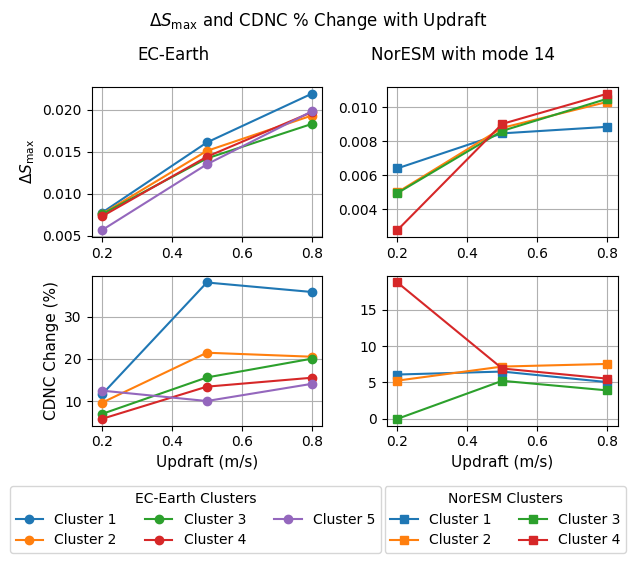

In [104]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import matplotlib.cm as cm
from matplotlib.lines import Line2D

fig, axs = plt.subplots(2, 2, figsize=(6.3, 5))

# --- Plot 1 ---
data1 = {'Updraft': [0.2]*5 + [0.5]*5 + [0.8]*5,
         'CDNC Change %': [11.62, 9.66, 7.00, 5.84, 12.50,
                      38.03, 21.45, 15.61, 13.44, 10.05,
                      35.79, 20.51, 20.04, 15.54, 14.10]
        } 
df1 = pd.DataFrame(data1)
grouped1 = df1.groupby(df1.index % 5)
for i, (_, group) in enumerate(grouped1):
    axs[1, 0].plot([0.2, 0.5, 0.8], group['CDNC Change %'].values, marker='o')
axs[1, 0].set_ylabel('CDNC Change (%)', fontsize = 11)
axs[1, 0].grid(True)
# --- Plot 2 ---
data2 = {
    'Updraft': [0.2]*4 + [0.5]*4 + [0.8]*4,
    'CDNC Change %': [6.090941,5.253674,-0.001635,18.745102,6.499669,7.186144,5.227916,6.919289,5.050942,7.546498,3.914012,5.531269]
}  
df2 = pd.DataFrame(data2)
grouped2 = df2.groupby(df2.index % 4)
for i, (_, group) in enumerate(grouped2):
    axs[1, 1].plot([0.2, 0.5, 0.8], group['CDNC Change %'].values, marker='s')
axs[1, 1].grid(True)

# --- Plot 3 ---
data3 = {'Updraft': [0.2]*5 + [0.5]*5 + [0.8]*5,
         'Smax Change': [0.00774,0.00758,0.00755,0.00730,0.00566,0.0161,0.0151,0.0142,0.0144,0.0135,0.0219,0.0193,0.0183,0.0197,0.0198]
}
df3 = pd.DataFrame(data3)
grouped3 = df3.groupby(df3.index % 5)
for i, (_, group) in enumerate(grouped3):
    axs[0, 0].plot([0.2, 0.5, 0.8], group['Smax Change'].values, marker='o')
axs[0, 0].set_ylabel(r'$\Delta S_{\mathrm{max}}$', fontsize = 11)
axs[1, 0].set_xlabel('Updraft (m/s)',fontsize = 11)
axs[0, 0].grid(True)
# --- Plot 4 ---
data4 = {
    'Updraft': [0.2]*4 + [0.5]*4 + [0.8]*4,
    'Smax Change': [0.006403,0.004995,0.004949,0.002774,0.00846,0.008782,0.008604,0.009015,0.008843,0.010306,0.010489,0.010786]
}
df4 = pd.DataFrame(data4)
grouped4 = df4.groupby(df4.index % 4)
for i, (_, group) in enumerate(grouped4):
    axs[0, 1].plot([0.2, 0.5, 0.8], group['Smax Change'].values, marker='s')
axs[1, 1].set_xlabel('Updraft (m/s)', fontsize = 11)
axs[0, 1].grid(True)


plt.tight_layout()
plt.suptitle(r'$\Delta S_{\mathrm{max}}$ and CDNC % Change with Updraft', fontsize=12, y=1.00)
fig.text(0.27, .9, 'EC-Earth', ha='center', fontsize=12)
fig.text(0.73, .9, 'NorESM with mode 14', ha='center', fontsize=12)
# Define consistent color maps
colors_cdnc = cm.tab10(range(6))  # For EC-Earth (6 clusters)
colors_smax = cm.tab10(range(4))  # For NorESM (4 clusters)

# Custom legend handles
cdnc_legend_handles = [Line2D([0], [0], color=colors_cdnc[i], marker='o', label=f'Cluster {i+1}', linestyle='-') for i in range(5)]
smax_legend_handles = [Line2D([0], [0], color=colors_smax[i], marker='s', label=f'Cluster {i+1}', linestyle='-') for i in range(4)]

# Place EC-Earth legend under column 1
fig.legend(handles=cdnc_legend_handles, loc='lower left', bbox_to_anchor=(0.00, -0.1), ncol=3, title="EC-Earth Clusters")

# Place NorESM legend under column 2
fig.legend(handles=smax_legend_handles, loc='lower right', bbox_to_anchor=(1, -0.1), ncol=2, title="NorESM Clusters")

# Adjust layout to make room for legends
plt.tight_layout(rect=[0, 0.050, 1, 0.95])
plt.show()


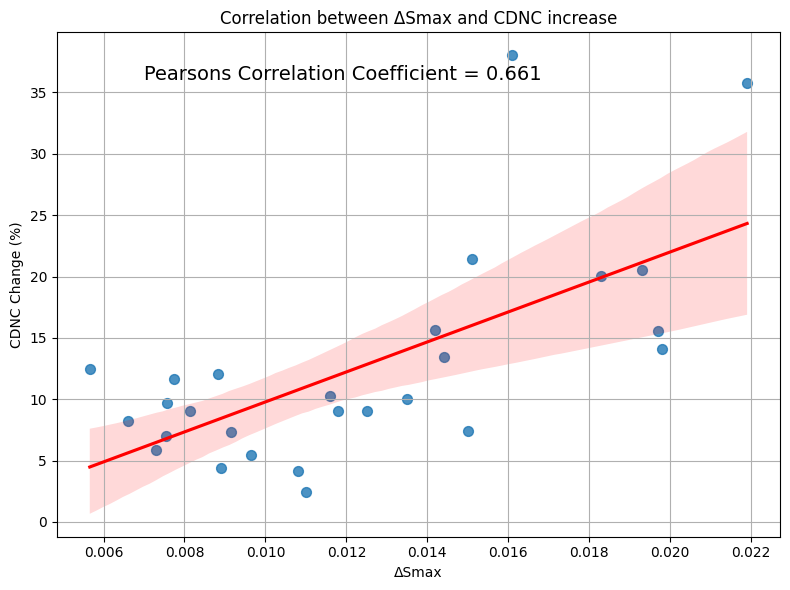

In [26]:
# Re-import necessary libraries after kernel reset
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Provided data
x_values = [
    0.00914, 0.00882, 0.00813, 0.00965, 0.0089, 0.0116, 0.0108, 0.0118, 0.0066, 0.0125, 0.0110, 0.0150,
    0.00774, 0.00758, 0.00755, 0.00730, 0.00566, 0.0161, 0.0151, 0.0142, 0.0144, 0.0135, 0.0219, 0.0193,
    0.0183, 0.0197, 0.0198
]
y_values = [
    7.339, 12.04, 9.032, 5.426, 4.401, 10.246, 4.145, 9.036, 8.206, 9.025, 2.439, 7.426,
    11.62, 9.66, 7.00, 5.84, 12.50, 38.03, 21.45, 15.61, 13.44, 10.05, 35.79, 20.51,
    20.04, 15.54, 14.10
]

# Create DataFrame
df = pd.DataFrame({'Smax': x_values, 'CDNC Change (%)': y_values})

# Plot correlation
plt.figure(figsize=(8, 6))
sns.regplot(data=df, x='Smax', y='CDNC Change (%)', scatter_kws={'s': 50}, line_kws={'color': 'red'})
plt.title('Correlation between ΔSmax and CDNC increase')
plt.text(0.007,36,f'Pearsons Correlation Coefficient = {np.corrcoef(x_values, y_values)[1][0]:.3f}', fontsize = 14)    

plt.grid(True)
plt.xlabel("ΔSmax")
plt.ylabel("CDNC Change (%)")
plt.tight_layout()
plt.show()


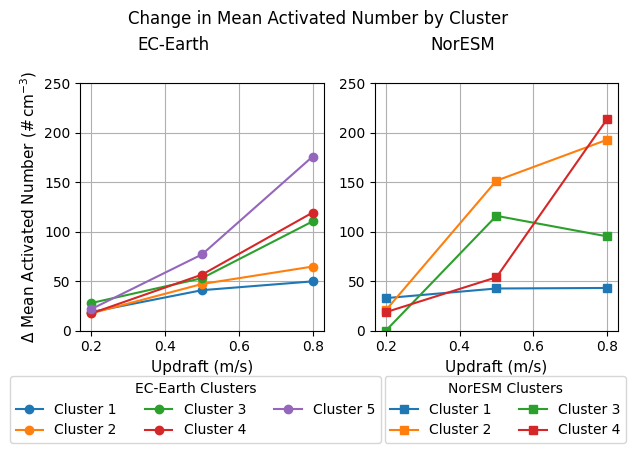

In [27]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import matplotlib.cm as cm
from matplotlib.lines import Line2D

fig, axs = plt.subplots(1, 2, figsize=(6.3, 4))

# --- Plot 1 ---
data1 = {'Updraft': [0.2]*5 + [0.5]*5 + [0.8]*5,
         'Activated Number Change': [18.91,17.62,27.97,17.51,21.90,40.95,47.20,53.09,56.68,77.12,49.84,64.84,110.5,119.44,176.07]
        } 
df1 = pd.DataFrame(data1)
grouped1 = df1.groupby(df1.index % 5)
for i, (_, group) in enumerate(grouped1):
    axs[0].plot([0.2, 0.5, 0.8], group['Activated Number Change'].values, marker='o')
axs[0].set_ylabel(r'$\Delta$ Mean Activated Number ($\# \, \mathrm{cm}^{-3}$)', fontsize = 11)
axs[0].set_xlabel('Updraft (m/s)', fontsize = 11)
axs[0].set_ylim([0,250])
axs[0].grid(True)
# --- Plot 2 ---
data2 = {
    'Updraft': [0.2]*4 + [0.5]*4 + [0.8]*4,
    'Activated Number Change': [32.91,20.67,0.00,18.70,42.65,151.66,116.11,53.97,43.17,193.05,95.38,213.79]
}  
df2 = pd.DataFrame(data2)
grouped2 = df2.groupby(df2.index % 4)
for i, (_, group) in enumerate(grouped2):
    axs[1].plot([0.2, 0.5, 0.8], group['Activated Number Change'].values, marker='s')
axs[1].set_xlabel('Updraft (m/s)', fontsize = 11)
axs[1].grid(True)
axs[1].set_ylim([0,250])
plt.tight_layout()
plt.suptitle('Change in Mean Activated Number by Cluster', fontsize=12, y=1.00)
fig.text(0.27, .9, 'EC-Earth', ha='center', fontsize=12)
fig.text(0.73, .9, 'NorESM', ha='center', fontsize=12)
# Define consistent color maps
colors_cdnc = cm.tab10(range(6))  # For EC-Earth (6 clusters)
colors_smax = cm.tab10(range(4))  # For NorESM (4 clusters)

# Custom legend handles
cdnc_legend_handles = [Line2D([0], [0], color=colors_cdnc[i], marker='o', label=f'Cluster {i+1}', linestyle='-') for i in range(5)]
smax_legend_handles = [Line2D([0], [0], color=colors_smax[i], marker='s', label=f'Cluster {i+1}', linestyle='-') for i in range(4)]

# Place EC-Earth legend under column 1
fig.legend(handles=cdnc_legend_handles, loc='lower left', bbox_to_anchor=(0.00, -0.1), ncol=3, title="EC-Earth Clusters")

# Place NorESM legend under column 2
fig.legend(handles=smax_legend_handles, loc='lower right', bbox_to_anchor=(1, -0.1), ncol=2, title="NorESM Clusters")

# Adjust layout to make room for legends
plt.tight_layout(rect=[0, 0.050, 1, 0.95])
plt.show()


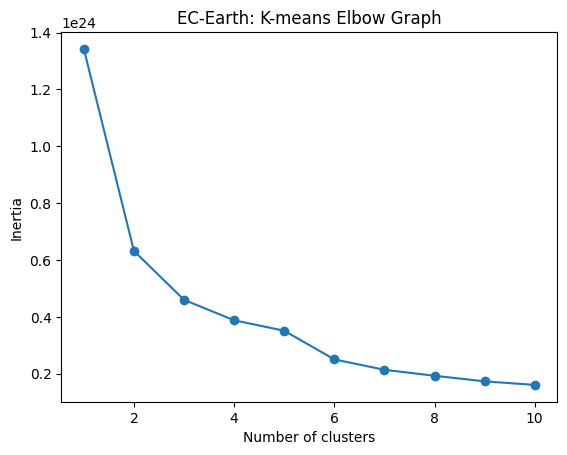

In [28]:
sizedist4clust =ECearth_ds['Tot_dis'].isel(lev=0).T
sizedist4clust=sizedist4clust.dropna(dim='time')
n = 2
inertias = [] 
for i in range(1,11):
    kmeans = KMeans(n_clusters=i, random_state=n)
    kmeans.fit(sizedist4clust)
    inertias.append(kmeans.inertia_)
plt.plot(range(1,11), inertias, marker='o')
plt.title(f'EC-Earth: K-means Elbow Graph')
plt.xlabel('Number of clusters')
plt.ylabel('Inertia')
plt.show()

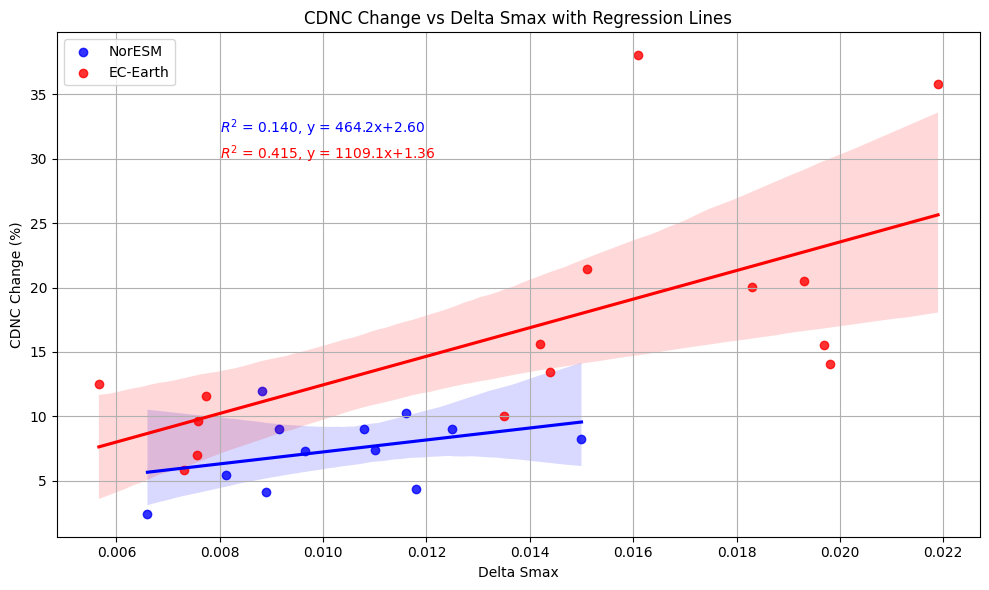

In [29]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
import numpy as np
from scipy.stats import linregress


# Data
x = [0.00914,0.00882,0.00813,0.00965,0.0089,0.0116,0.0108,0.0118,0.0066,0.0125,0.0110,0.0150,0.00774,0.00758,0.00755,0.00730,0.00566,0.0161,0.0151,0.0142,0.0144,0.0135,0.0219,0.0193,0.0183,0.0197,0.0198]
y = [9.03,12.0,5.43,7.34,4.15,10.25,9.04,4.40,2.44,9.03,7.43,8.21,11.62,9.66,7.00,5.84,12.50,38.03,21.45,15.61,13.44,10.05,35.79,20.51,20.04,15.54,14.10]

# Creating a DataFrame and labeling groups
df = pd.DataFrame({'Delta_Smax': x, 'CDNC_Change': y})
df['Group'] = ['NorESM'] * 12 + ['EC-Earth'] * 15
# Group 1 (first 12 points)
slope1, intercept1, r_value1, _, _ = linregress(x[:12], y[:12])
r_squared1 = r_value1**2

# Group 2 (last 15 points)
slope2, intercept2, r_value2, _, _ = linregress(x[12:], y[12:])
r_squared2 = r_value2**2
# Plot with seaborn's regplot
plt.figure(figsize=(10, 6))
palette = {'NorESM': 'blue', 'EC-Earth': 'red'}

# Plot each group separately with regression line and R^2
for group in df['Group'].unique():
    subset = df[df['Group'] == group]
    sns.regplot(data=subset, x='Delta_Smax', y='CDNC_Change', label=f'{group}', color=palette[group])
    
    # Calculate and plot R^2
    model = LinearRegression()
    X_group = subset['Delta_Smax'].values.reshape(-1, 1)
    y_group = subset['CDNC_Change'].values
    model.fit(X_group, y_group)
    r2 = r2_score(y_group, model.predict(X_group))

    # Annotate R^2
    x_pos = 0.008
    if group == 'EC-Earth':
        y_pos = 30
        plt.text(x_pos, y_pos, f'$R^2$ = {r2:.3f}, y = {slope2:.1f}x+{intercept2:.2f}', color=palette[group])
    else:
        y_pos = 32
        plt.text(x_pos, y_pos, f'$R^2$ = {r2:.3f}, y = {slope1:.1f}x+{intercept1:.2f}', color=palette[group])
plt.xlabel('Delta Smax')
plt.ylabel('CDNC Change (%)')
plt.title('CDNC Change vs Delta Smax with Regression Lines')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [30]:
from scipy.stats import linregress


print(f"Group 1: slope = {slope1:.4f}, intercept = {intercept1:.4f}, R² = {r_squared1:.4f}")
print(f"Group 2: slope = {slope2:.4f}, intercept = {intercept2:.4f}, R² = {r_squared2:.4f}")

Group 1: slope = 464.2088, intercept = 2.6013, R² = 0.1401
Group 2: slope = 1109.0619, intercept = 1.3567, R² = 0.4151


In [31]:
linregress(x[:12], y[:12])

LinregressResult(slope=np.float64(464.20875178014387), intercept=np.float64(2.601330608697414), rvalue=np.float64(0.3743354838483315), pvalue=np.float64(0.2306027808374081), stderr=np.float64(363.63817532737266), intercept_stderr=np.float64(3.836930465739938))

In [32]:
linregress(x[12:], y[12:])

LinregressResult(slope=np.float64(1109.061862365968), intercept=np.float64(1.3567303057180702), rvalue=np.float64(0.6443029558416141), pvalue=np.float64(0.009524505461396063), stderr=np.float64(365.1110847408114), intercept_stderr=np.float64(5.419804916753724))

In [33]:
#EC-Earth Activation Radius from PARSEC
ECActR = [np.float64(361.54046296644844), 
 np.float64(203.16583101639702),
 np.float64(141.33523429255584),
 np.float64(251.5108263233402),
 np.float64(304.7839531499037),
 np.float64(141.33523429255584),
 np.float64(268.14425005353365),
 np.float64(124.34457265169122),
 np.float64(92.22282316159196),
 np.float64(160.6475298965127),
 np.float64(203.16583101639702),
 np.float64(96.24531891583946),
 np.float64(207.54929878718698),
 np.float64(98.3218898207321),
 np.float64(76.1032141604749),
 np.float64(121.71839935273819),
 np.float64(157.25463349130524),
 np.float64(81.13622616582478)]
ECActRdf = np.array(ECActR).reshape(3, 6)

ECActR_df = pd.DataFrame(ECActRdf, columns=["Cluster 1", "Cluster 2", "Cluster 3","Cluster 4", "Cluster 5", "Cluster 6"], index =['Updraft 1', 'Updraft2', 'Updraft 3'])
ECActR_df
ECActR_CC = [np.nan,
 np.float64(190.56312424898383),
 np.float64(127.02740777196964),
 np.float64(240.99913346981475),
 np.float64(285.87770907458366),
 np.float64(127.02740777196964),
 np.float64(207.54929878718698),
 np.float64(102.61040941702),
 np.float64(72.92254148679628),
 np.float64(141.33523429255584),
 np.float64(186.53840665982455),
 np.float64(77.74520280028237),
 np.float64(144.38465673381506),
 np.float64(74.49590453102621),
 np.float64(57.66139958192239),
 np.float64(98.3218898207321),
 np.float64(132.5679799526813),
 np.float64(64.15613419567872)]
ECActR_CCdf = np.array(ECActR_CC).reshape(3, 6)

ECActR_CC_df = pd.DataFrame(ECActR_CCdf, columns=["Cluster 1", "Cluster 2", "Cluster 3","Cluster 4", "Cluster 5", "Cluster 6"], index =['Updraft 1', 'Updraft2', 'Updraft 3'])
ECActRdf

array([[361.54046297, 203.16583102, 141.33523429, 251.51082632,
        304.78395315, 141.33523429],
       [268.14425005, 124.34457265,  92.22282316, 160.6475299 ,
        203.16583102,  96.24531892],
       [207.54929879,  98.32188982,  76.10321416, 121.71839935,
        157.25463349,  81.13622617]])

In [34]:
ECActR_df

,Cluster 1,Cluster 2,Cluster 3,Cluster 4,Cluster 5,Cluster 6
Updraft 1,361.540463,203.165831,141.335234,251.510826,304.783953,141.335234
Updraft2,268.144250,124.344573,92.222823,160.647530,203.165831,96.245319
Updraft 3,207.549299,98.321890,76.103214,121.718399,157.254633,81.136226


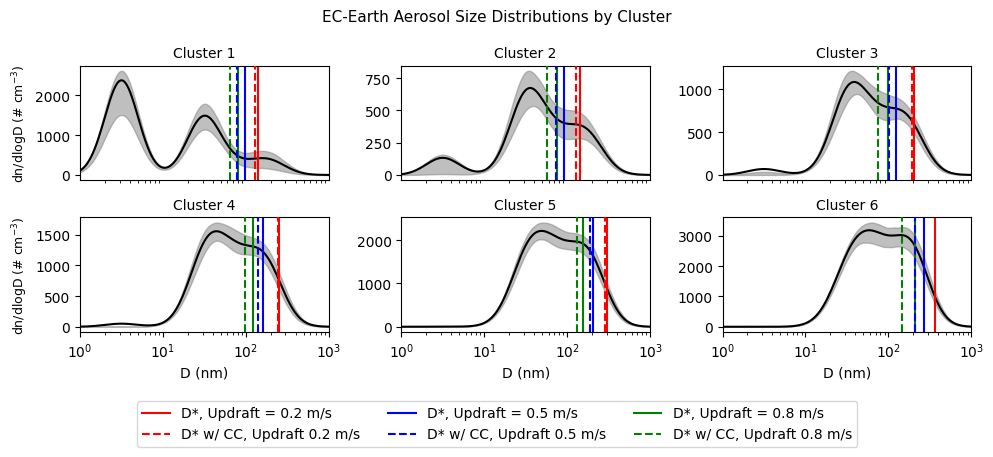

In [35]:
ECGroup = ECearth_ds.groupby(ECearth_ds['label'])
NorGroup = NorESM_ds.groupby(NorESM_ds['label'])
cm = 1/2.54
fig, ax = plt.subplots(2, 3, figsize=(25.5*cm,10*cm)) 
colors = ['red','blue','green']
legend_handles = []
order = [5,2,1,3,4,0]
Updraftvel = [0.2, 0.5,0.8]
for plot_idx, i in enumerate(order):
    axis = ax.flatten()[plot_idx]
    axis.plot(ECGroup[i]['D'],ECGroup[i]['Tot_dis'].isel(lev = 0).mean('time')/1E6, color = 'black')
    axis.set_xscale('log')
    axis.set_xlim([1,1000])
    axis.set_title(f'Cluster {plot_idx+1}', fontsize = 10)
    axis.fill_between(ECGroup[i]['D'],(ECGroup[i]['Tot_dis']*1E-6).isel(lev = 0).quantile(0.75, dim='time'),(ECGroup[i]['Tot_dis']*1E-6).isel(lev = 0).quantile(0.25, dim='time'),color='gray', alpha=0.5, label = 'Interquartile Range')
    if i in (3,5): 
        axis.set_ylabel(r'$\text{dn/dlogD } (\#\ \text{cm}^{-3})$', fontsize = 9)
    if i in (5,2,1):
        axis.set_xticks([])
    else:
        axis.set_xlabel('D (nm)')

    for n in range(3):
        h1 = axis.axvline(ECActR_df.iloc[n,i], color = colors[n], label = f'D*, Updraft = {Updraftvel[n]} m/s')
        h2 = axis.axvline(ECActR_CC_df.iloc[n,i], color = colors[n], ls = '--', zorder=1000,label = f'D* w/ CC, Updraft {Updraftvel[n]} m/s')
        if i == 0:

            legend_handles.extend([h1, h2])
fig.suptitle('EC-Earth Aerosol Size Distributions by Cluster', fontsize = 11)            
fig.legend(handles=legend_handles, loc="lower center", bbox_to_anchor=(0.5,-0.15), ncol = 3)
plt.subplots_adjust(bottom=0.13)  
plt.tight_layout()
plt.show()

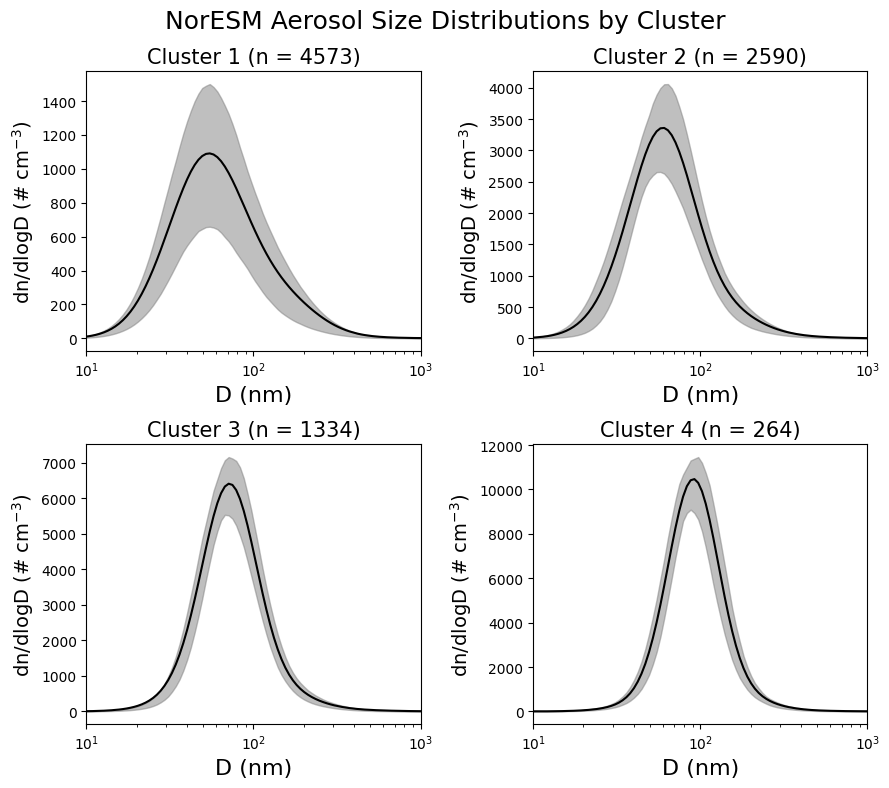

In [36]:
fig, ax = plt.subplots(2, 2, figsize=(9, 8)) 
colors = ['red','blue','green']
order = [3,1,0,2]


legend_handles = []
for plot_idx, i in enumerate(order):
    axis = ax.flatten()[plot_idx]
    axis.plot(NorGroup[i]['D'],NorGroup[i]['Tot_dis'].isel(lev = -1).mean('time'), color = 'black')
    axis.set_xscale('log')
    axis.set_xlim([10,1000])
    axis.set_title(f'Cluster {plot_idx+1} (n = {len(NorGroup[i]['T'].dropna('time'))})', fontsize = 15)
    axis.set_xlabel('D (nm)', fontsize = 16)
    axis.set_ylabel(r'$\text{dn/dlogD } (\#\ \text{cm}^{-3})$',fontsize = 14)
    axis.fill_between(NorGroup[i]['D'],NorGroup[i]['Tot_dis'].isel(lev = -1).quantile(0.75, dim='time'),NorGroup[i]['Tot_dis'].isel(lev = -1).quantile(0.25, dim='time'),color='gray', alpha=0.5, label = 'Interquartile Range')

fig.suptitle('NorESM Aerosol Size Distributions by Cluster', fontsize = 18)                        
plt.subplots_adjust(bottom=0.25)  
plt.tight_layout()
plt.show()

In [54]:
NorActR = [np.float64(212.0273434344203),
 np.float64(174.96712605504354),
 np.float64(273.9296799762329),
 np.float64(119.14769117018751),
 np.float64(164.11363079662692),
 np.float64(124.34457265169122),
 np.float64(226.04956544882387),
 np.float64(81.13622616582478),
 np.float64(141.33523429255584),
 np.float64(102.61040941702),
 np.float64(194.67467838811976),
 np.float64(66.95444125855037)]
NorActR_CC = [np.float64(207.54929878718698),
 np.float64(171.27179794508717),
 np.float64(262.4810091517297),
 np.float64(114.16800917360587),
 np.float64(164.11363079662692),
 np.float64(119.14769117018751),
 np.float64(216.60200553100083),
 np.float64(74.49590453102621),
 np.float64(138.3502160437893),
 np.float64(96.24531891583946),
 np.float64(190.56312424898383),
 np.float64(60.17642489833283)]

In [55]:
NorActR_CCno14 = [np.float64(167.65451563806593),
 np.float64(121.71839935273819),
 np.float64(221.2753696768497),
 np.float64(74.49590453102621),
 np.float64(119.14769117018751),
 np.float64(82.88680612635326),
 np.float64(171.27179794508717),
 np.float64(54.08456923060725),
 np.float64(98.3218898207321),
 np.float64(68.39903769437733),
 np.float64(138.3502160437893),
 np.float64(46.57782066434512)]
NorActR_CC= np.array(NorActR_CC).reshape(3, 4)

NorActR_CC_df = pd.DataFrame(NorActR_CC, columns=["Cluster 1", "Cluster 2", "Cluster 3","Cluster 4"], index =['Updraft 1', 'Updraft2', 'Updraft 3'])

In [56]:
NorActRno14 = [np.float64(171.27179794508717),
 np.float64(129.7681272383768),
 np.float64(226.04956544882387),
 np.float64(82.88680612635326),
 np.float64(127.02740777196964),
 np.float64(92.22282316159196),
 np.float64(174.96712605504354),
 np.float64(60.17642489833283),
 np.float64(107.08598197131427),
 np.float64(79.42261867825579),
 np.float64(147.49987294031467),
 np.float64(50.72961548053402)]
NorActR= np.array(NorActR).reshape(3, 4)

NorActR_df = pd.DataFrame(NorActR, columns=["Cluster 1", "Cluster 2", "Cluster 3","Cluster 4"], index =['Updraft 1', 'Updraft2', 'Updraft 3'])

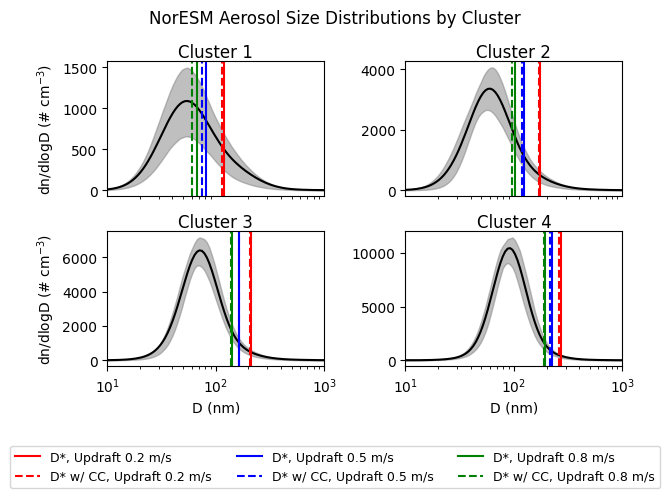

In [59]:
fig, ax = plt.subplots(2, 2, figsize=(16*cm, 11*cm)) 
colors = ['red','blue','green']
legend_handles = []
for plot_idx, i in enumerate(order):
    axis = ax.flatten()[plot_idx]
    axis.plot(NorGroup[i]['D'],NorGroup[i]['Tot_dis'].isel(lev = -1).mean('time'), color = 'black')
    axis.set_xscale('log')
    axis.set_xlim([10,1000])
    axis.set_title(f'Cluster {plot_idx+1}', y = 0.97)
    if plot_idx in (2,3):
        axis.set_xlabel('D (nm)')
    if plot_idx in (0,2):
        axis.set_ylabel(r'$\text{dn/dlogD } (\#\ \text{cm}^{-3})$')
    if plot_idx in (0,1):
        axis.set_xticks([])       
    axis.fill_between(NorGroup[i]['D'],NorGroup[i]['Tot_dis'].isel(lev = -1).quantile(0.75, dim='time'),NorGroup[i]['Tot_dis'].isel(lev = -1).quantile(0.25, dim='time'),color='gray', alpha=0.5, label = 'Interquartile Range')
    for n in range(3):
        h1 = axis.axvline(NorActR_df.iloc[n,i], color = colors[n], label = f'D*, Updraft {Updraftvel[n]} m/s')
        h2 = axis.axvline(NorActR_CC_df.iloc[n,i], color = colors[n], ls = '--', label = f'D* w/ CC, Updraft {Updraftvel[n]} m/s')
        if i == 0:

            legend_handles.extend([h1, h2])
fig.suptitle('NorESM Aerosol Size Distributions by Cluster', y = 0.97)                        
fig.legend(handles=legend_handles, loc="lower center", bbox_to_anchor=(0.5,-0.15), ncol = 3, fontsize = 9)
plt.subplots_adjust(bottom=0.00)  
plt.tight_layout()
plt.show()

In [60]:
def NdtoCCNGraph(x,y):
    
    x = x.to_numpy()
    y = y.to_numpy()
    Y = np.log10(y)
    X = np.log10(x)
    X = sm.add_constant(X)
    model = sm.OLS(Y,X).fit()
    res = stats.linregress(np.log10(x),np.log10(y))
    lims = [1,10000]
    fig = plt.hexbin(x,y,gridsize=50, bins= 'log', xscale='log', yscale='log',edgecolors = 'face', cmap ='inferno',extent = [0,4,0,4], mincnt = 1)
    plt.xlim(lims)
    plt.ylim(lims)
    plt.plot([1,10000],[10**res.intercept*1**res.slope,10**res.intercept*10000**res.slope])
    plt.plot(lims,lims)
    plt.colorbar()
    
    return fig
def Susceptibility(x,y):
    x = x.to_numpy()
    y = y.to_numpy()
    Y = np.log10(y)
    X = np.log10(x)
    X = sm.add_constant(X)
    model = sm.OLS(Y,X).fit()
    parameters = model.params
    sterrs = model.bse
    S = parameters[1]
    Sterr = sterrs[1]
    return S, Sterr
x = xr.DataArray(np.logspace(-0.5,4, num=200), dims =['D'], coords= {'D':np.logspace(-0.5,4, num=200)})

dx = xr.DataArray(np.logspace(-0.5,4, num=200), dims =['D'], coords= {'D':np.logspace(-0.5,4, num=200)})
for i in range (1,len(dx)):
    dx[i]= np.log10(x[i]/x[i-1])
dx[0] =dx[1]

In [61]:
NorDiameterUp1NoCC = []
NorDiameterUp2NoCC = []
NorDiameterUp3NoCC = []
NorDiameterUp1CC = []
NorDiameterUp2CC = []
NorDiameterUp3CC = []

ListVarNor_ = [NorDiameterUp1NoCC,NorDiameterUp2NoCC,NorDiameterUp3NoCC,NorDiameterUp1CC,NorDiameterUp2CC,NorDiameterUp3CC]
ClusterWeight = []
z = -1
for i in range(4):
    ClusterWeight.append(len(NorGroup[i]['Droplets'].isel(lev = z).dropna('time'))/len(NorESM_ds['Droplets'].isel(lev = z).dropna('time')))
for i in range(3):
    ListVarNor_[i].append(sum(ClusterWeight*NorActR_df.values[i]))
    ListVarNor_[i+3].append(sum(ClusterWeight*NorActR_CC_df.values[i]))

In [62]:
NorDiameterUp1CC

[np.float64(117.82251271192558)]

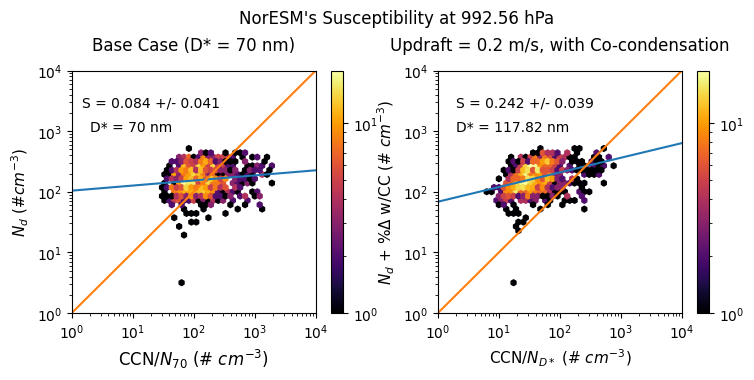

In [63]:
z = -1
i = 0
plt.figure(figsize = (22*cm,8*cm))
plt.subplot(1,2,1)
x =NorESM_ds['TotN70'].isel(lev = z).where(NorESM_ds['Droplets'].isel(lev = z)>0).dropna('time')
y = NorESM_ds['Droplets'].isel(lev = z).dropna('time')
Sus = Susceptibility(x,y)
plt.ylabel('$N_d$ (#$ cm^{-3}$)', fontsize = 11)
plt.xlabel('CCN/$N_{70}$ (# $cm^{-3}$)',fontsize = 12)
plt.text(1.5,2500,f'S = {Sus[0]:.3f} +/- {Sus[1]*1.98:.3f}', fontsize = 10)
plt.text(2,1000,'D* = 70 nm', fontsize = 10)
NdtoCCNGraph(x,y)
plt.title('Base Case (D* = 70 nm)', y = 1.05)
plt.subplot(1,2,2)
x =NorESM_ds['Tot_dis'].isel(lev = z).where(NorESM_ds['D']>NorDiameterUp1CC).sum('D')*dx[0].where(NorESM_ds['DropletsCCUp1'].isel(lev = z)>0).dropna('time')
y = NorESM_ds['DropletsCCUp1'].isel(lev = z).dropna('time')
Sus = Susceptibility(x,y)
plt.text(2,2500,f'S = {Sus[0]:.3f} +/- {Sus[1]*1.98:.3f}', fontsize = 10)
plt.text(2,1000,f'D* = {NorDiameterUp1CC[0]:.2f} nm', fontsize = 10)
plt.xlabel('CCN/$N_{D*}$ (# $cm^{-3}$)',fontsize = 11)
plt.ylabel(r'$N_d$ + %$\Delta$ w/CC (# $cm^{-3}$)', fontsize = 11)
plt.title('Updraft = 0.2 m/s, with Co-condensation', y = 1.05)
plt.suptitle(f'NorESM\'s Susceptibility at {NorESM_ds['lev'].isel(lev = z).values:.2f} hPa', y = 1.075)
NdtoCCNGraph(x,y)

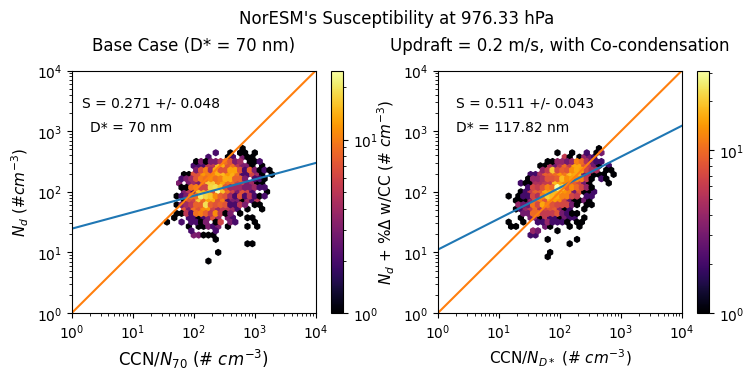

In [64]:
z = -2
i = 0
plt.figure(figsize = (22*cm,8*cm))
plt.subplot(1,2,1)
x =NorESM_ds['TotN70'].isel(lev = z).where(NorESM_ds['Droplets'].isel(lev = z)>0).dropna('time')
y = NorESM_ds['Droplets'].isel(lev = z).dropna('time')
Sus = Susceptibility(x,y)
plt.ylabel('$N_d$ (#$ cm^{-3}$)', fontsize = 11)
plt.xlabel('CCN/$N_{70}$ (# $cm^{-3}$)',fontsize = 12)
plt.text(1.5,2500,f'S = {Sus[0]:.3f} +/- {Sus[1]*1.98:.3f}', fontsize = 10)
plt.text(2,1000,'D* = 70 nm', fontsize = 10)
NdtoCCNGraph(x,y)
plt.title('Base Case (D* = 70 nm)', y = 1.05)
plt.subplot(1,2,2)
x =NorESM_ds['Tot_dis'].isel(lev = z).where(NorESM_ds['D']>NorDiameterUp1CC).sum('D')*dx[0].where(NorESM_ds['DropletsCCUp1'].isel(lev = z)>0).dropna('time')
y = NorESM_ds['DropletsCCUp1'].isel(lev = z).dropna('time')
Sus = Susceptibility(x,y)
plt.text(2,2500,f'S = {Sus[0]:.3f} +/- {Sus[1]*1.98:.3f}', fontsize = 10)
plt.text(2,1000,f'D* = {NorDiameterUp1CC[0]:.2f} nm', fontsize = 10)
plt.xlabel('CCN/$N_{D*}$ (# $cm^{-3}$)',fontsize = 11)
plt.ylabel(r'$N_d$ + %$\Delta$ w/CC (# $cm^{-3}$)', fontsize = 11)
plt.title('Updraft = 0.2 m/s, with Co-condensation', y = 1.05)
plt.suptitle(f'NorESM\'s Susceptibility at {NorESM_ds['lev'].isel(lev = z).values:.2f} hPa', y = 1.075)
NdtoCCNGraph(x,y)

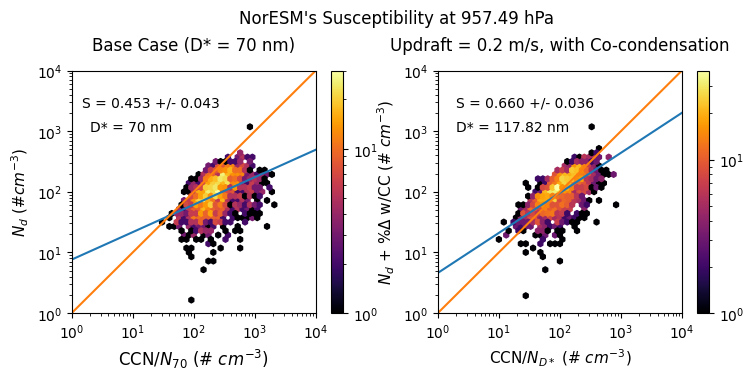

In [65]:
z = -3
i = 0
plt.figure(figsize = (22*cm,8*cm))
plt.subplot(1,2,1)
x =NorESM_ds['TotN70'].isel(lev = z).where(NorESM_ds['Droplets'].isel(lev = z)>0).dropna('time')
y = NorESM_ds['Droplets'].isel(lev = z).dropna('time')
Sus = Susceptibility(x,y)
plt.ylabel('$N_d$ (#$ cm^{-3}$)', fontsize = 11)
plt.xlabel('CCN/$N_{70}$ (# $cm^{-3}$)',fontsize = 12)
plt.text(1.5,2500,f'S = {Sus[0]:.3f} +/- {Sus[1]*1.98:.3f}', fontsize = 10)
plt.text(2,1000,'D* = 70 nm', fontsize = 10)
NdtoCCNGraph(x,y)
plt.title('Base Case (D* = 70 nm)', y = 1.05)
plt.subplot(1,2,2)
x =NorESM_ds['Tot_dis'].isel(lev = z).where(NorESM_ds['D']>NorDiameterUp1CC).sum('D')*dx[0].where(NorESM_ds['DropletsCCUp1'].isel(lev = z)>0).dropna('time')
y = NorESM_ds['DropletsCCUp1'].isel(lev = z).dropna('time')
Sus = Susceptibility(x,y)
plt.text(2,2500,f'S = {Sus[0]:.3f} +/- {Sus[1]*1.98:.3f}', fontsize = 10)
plt.text(2,1000,f'D* = {NorDiameterUp1CC[0]:.2f} nm', fontsize = 10)
plt.xlabel('CCN/$N_{D*}$ (# $cm^{-3}$)',fontsize = 11)
plt.ylabel(r'$N_d$ + %$\Delta$ w/CC (# $cm^{-3}$)', fontsize = 11)
plt.title('Updraft = 0.2 m/s, with Co-condensation', y = 1.05)
plt.suptitle(f'NorESM\'s Susceptibility at {NorESM_ds['lev'].isel(lev = z).values:.2f} hPa', y = 1.075)
NdtoCCNGraph(x,y)

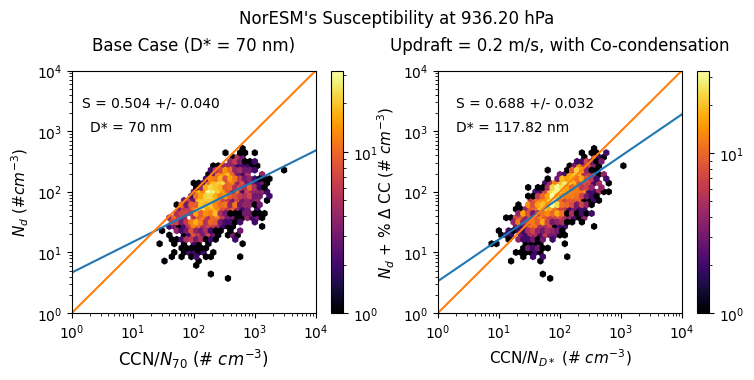

In [66]:
z = -4
i = 0
plt.figure(figsize = (22*cm,8*cm))
plt.subplot(1,2,1)
x1 =NorESM_ds['TotN70'].isel(lev = z).where(NorESM_ds['Droplets'].isel(lev = z)>0).dropna('time')
y1 = NorESM_ds['Droplets'].isel(lev = z).dropna('time')
Sus = Susceptibility(x1,y1)
plt.ylabel('$N_d$ (#$ cm^{-3}$)', fontsize = 11)
plt.xlabel('CCN/$N_{70}$ (# $cm^{-3}$)',fontsize = 12)
plt.text(1.5,2500,f'S = {Sus[0]:.3f} +/- {Sus[1]*1.98:.3f}', fontsize = 10)
plt.text(2,1000,'D* = 70 nm', fontsize = 10)
NdtoCCNGraph(x1,y1)
plt.title('Base Case (D* = 70 nm)', y = 1.05)
plt.subplot(1,2,2)
x =NorESM_ds['Tot_dis'].isel(lev = z).where(NorESM_ds['D']>NorDiameterUp1CC).sum('D')*dx[0].where(NorESM_ds['DropletsCCUp1'].isel(lev = z)>0).dropna('time')
y = NorESM_ds['DropletsCCUp1'].isel(lev = z).dropna('time')
Sus = Susceptibility(x,y)
plt.text(2,2500,f'S = {Sus[0]:.3f} +/- {Sus[1]*1.98:.3f}', fontsize = 10)
plt.text(2,1000,f'D* = {NorDiameterUp1CC[0]:.2f} nm', fontsize = 10)
plt.xlabel('CCN/$N_{D*}$ (# $cm^{-3}$)',fontsize = 11)
plt.ylabel(r'$N_d$ + % $\Delta$ CC (# $cm^{-3}$)', fontsize = 11)
plt.title('Updraft = 0.2 m/s, with Co-condensation', y = 1.05)
plt.suptitle(f'NorESM\'s Susceptibility at {NorESM_ds['lev'].isel(lev = z).values:.2f} hPa', y = 1.075)
NdtoCCNGraph(x,y)

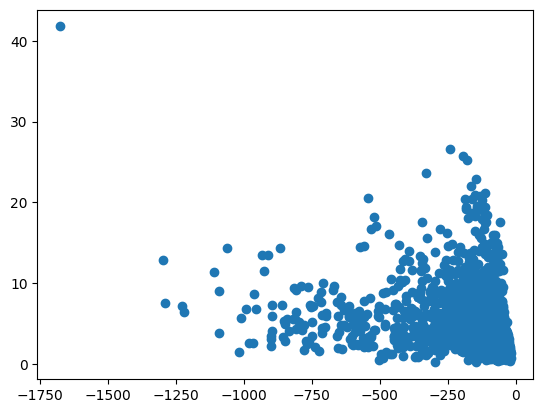

In [67]:
(.432-.383)/.383*100
y_ = y-y1
x_ = x-x1
plt.scatter(x_, y_)

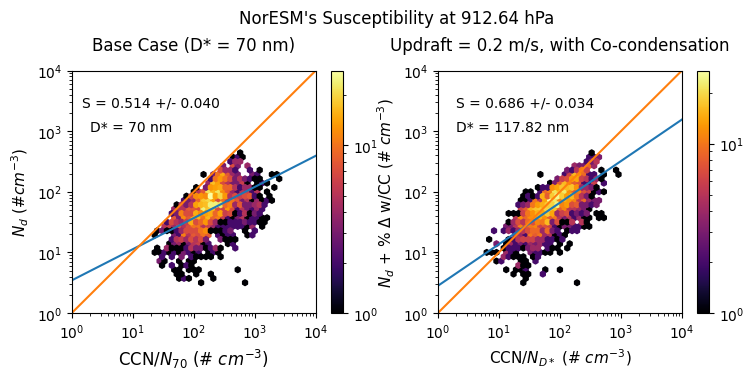

In [68]:
z = -5
i = 0
plt.figure(figsize = (22*cm,8*cm))
plt.subplot(1,2,1)
x =NorESM_ds['TotN70'].isel(lev = z).where(NorESM_ds['Droplets'].isel(lev = z)>0).dropna('time')
y = NorESM_ds['Droplets'].isel(lev = z).dropna('time')
Sus = Susceptibility(x,y)
plt.ylabel('$N_d$ (#$ cm^{-3}$)', fontsize = 11)
plt.xlabel('CCN/$N_{70}$ (# $cm^{-3}$)',fontsize = 12)
plt.text(1.5,2500,f'S = {Sus[0]:.3f} +/- {Sus[1]*1.98:.3f}', fontsize = 10)
plt.text(2,1000,'D* = 70 nm', fontsize = 10)
NdtoCCNGraph(x,y)
plt.title('Base Case (D* = 70 nm)', y = 1.05)
plt.subplot(1,2,2)
x =NorESM_ds['Tot_dis'].isel(lev = z).where(NorESM_ds['D']>NorDiameterUp1CC).sum('D')*dx[0].where(NorESM_ds['DropletsCCUp1'].isel(lev = z)>0).dropna('time')
y = NorESM_ds['DropletsCCUp1'].isel(lev = z).dropna('time')
Sus = Susceptibility(x,y)
plt.text(2,2500,f'S = {Sus[0]:.3f} +/- {Sus[1]*1.98:.3f}', fontsize = 10)
plt.text(2,1000,f'D* = {NorDiameterUp1CC[0]:.2f} nm', fontsize = 10)
plt.xlabel('CCN/$N_{D*}$ (# $cm^{-3}$)',fontsize = 11)
plt.ylabel(r'$N_d$ + % $\Delta$ w/CC (# $cm^{-3}$)', fontsize = 11)
plt.title('Updraft = 0.2 m/s, with Co-condensation', y = 1.05)
plt.suptitle(f'NorESM\'s Susceptibility at {NorESM_ds['lev'].isel(lev = z).values:.2f} hPa', y = 1.075)
NdtoCCNGraph(x,y)

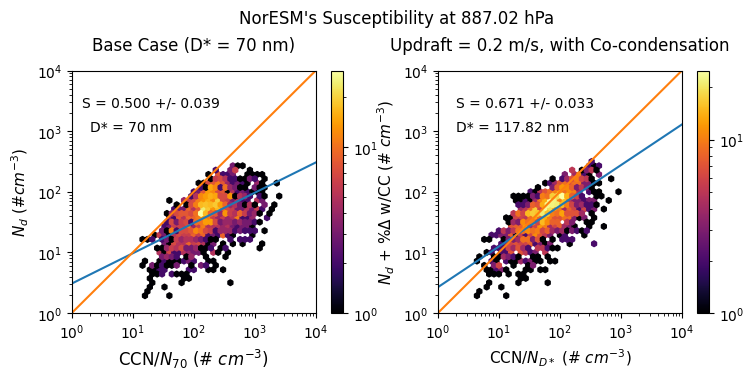

In [69]:
z = -6
i = 0
plt.figure(figsize = (22*cm,8*cm))
plt.subplot(1,2,1)
x =NorESM_ds['TotN70'].isel(lev = z).where(NorESM_ds['Droplets'].isel(lev = z)>0).dropna('time')
y = NorESM_ds['Droplets'].isel(lev = z).dropna('time')
Sus = Susceptibility(x,y)
plt.ylabel('$N_d$ (#$ cm^{-3}$)', fontsize = 11)
plt.xlabel('CCN/$N_{70}$ (# $cm^{-3}$)',fontsize = 12)
plt.text(1.5,2500,f'S = {Sus[0]:.3f} +/- {Sus[1]*1.98:.3f}', fontsize = 10)
plt.text(2,1000,'D* = 70 nm', fontsize = 10)
NdtoCCNGraph(x,y)
plt.title('Base Case (D* = 70 nm)', y = 1.05)
plt.subplot(1,2,2)
x =NorESM_ds['Tot_dis'].isel(lev = z).where(NorESM_ds['D']>NorDiameterUp1CC).sum('D')*dx[0].where(NorESM_ds['DropletsCCUp1'].isel(lev = z)>0).dropna('time')
y = NorESM_ds['DropletsCCUp1'].isel(lev = z).dropna('time')
Sus = Susceptibility(x,y)
plt.text(2,2500,f'S = {Sus[0]:.3f} +/- {Sus[1]*1.98:.3f}', fontsize = 10)
plt.text(2,1000,f'D* = {NorDiameterUp1CC[0]:.2f} nm', fontsize = 10)
plt.xlabel('CCN/$N_{D*}$ (# $cm^{-3}$)',fontsize = 11)
plt.ylabel(r'$N_d$ + %$\Delta$ w/CC (# $cm^{-3}$)', fontsize = 11)
plt.title('Updraft = 0.2 m/s, with Co-condensation', y = 1.05)
plt.suptitle(f'NorESM\'s Susceptibility at {NorESM_ds['lev'].isel(lev = z).values:.2f} hPa', y = 1.075)
NdtoCCNGraph(x,y)

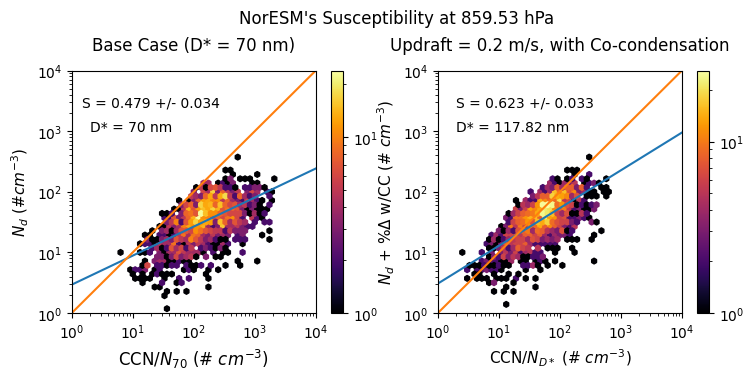

In [70]:
z = -7
i = 0
plt.figure(figsize = (22*cm,8*cm))
plt.subplot(1,2,1)
x =NorESM_ds['TotN70'].isel(lev = z).where(NorESM_ds['Droplets'].isel(lev = z)>0).dropna('time')
y = NorESM_ds['Droplets'].isel(lev = z).dropna('time')
Sus = Susceptibility(x,y)
plt.ylabel('$N_d$ (#$ cm^{-3}$)', fontsize = 11)
plt.xlabel('CCN/$N_{70}$ (# $cm^{-3}$)',fontsize = 12)
plt.text(1.5,2500,f'S = {Sus[0]:.3f} +/- {Sus[1]*1.98:.3f}', fontsize = 10)
plt.text(2,1000,'D* = 70 nm', fontsize = 10)
NdtoCCNGraph(x,y)
plt.title('Base Case (D* = 70 nm)', y = 1.05)
plt.subplot(1,2,2)
x =NorESM_ds['Tot_dis'].isel(lev = z).where(NorESM_ds['D']>NorDiameterUp1CC).sum('D')*dx[0].where(NorESM_ds['DropletsCCUp1'].isel(lev = z)>0).dropna('time')
y = NorESM_ds['DropletsCCUp1'].isel(lev = z).dropna('time')
Sus = Susceptibility(x,y)
plt.text(2,2500,f'S = {Sus[0]:.3f} +/- {Sus[1]*1.98:.3f}', fontsize = 10)
plt.text(2,1000,f'D* = {NorDiameterUp1CC[0]:.2f} nm', fontsize = 10)
plt.xlabel('CCN/$N_{D*}$ (# $cm^{-3}$)',fontsize = 11)
plt.ylabel(r'$N_d$ + %$\Delta$ w/CC (# $cm^{-3}$)', fontsize = 11)
plt.title('Updraft = 0.2 m/s, with Co-condensation', y = 1.05)
plt.suptitle(f'NorESM\'s Susceptibility at {NorESM_ds['lev'].isel(lev = z).values:.2f} hPa', y = 1.075)
NdtoCCNGraph(x,y)

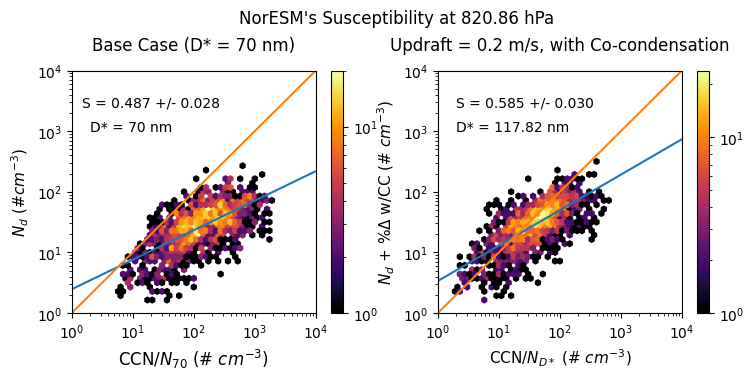

In [71]:
z = -8
i = 0
plt.figure(figsize = (22*cm,8*cm))
plt.subplot(1,2,1)
x =NorESM_ds['TotN70'].isel(lev = z).where(NorESM_ds['Droplets'].isel(lev = z)>0).dropna('time')
y = NorESM_ds['Droplets'].isel(lev = z).dropna('time')
Sus = Susceptibility(x,y)
plt.ylabel('$N_d$ (#$ cm^{-3}$)', fontsize = 11)
plt.xlabel('CCN/$N_{70}$ (# $cm^{-3}$)',fontsize = 12)
plt.text(1.5,2500,f'S = {Sus[0]:.3f} +/- {Sus[1]*1.98:.3f}', fontsize = 10)
plt.text(2,1000,'D* = 70 nm', fontsize = 10)
NdtoCCNGraph(x,y)
plt.title('Base Case (D* = 70 nm)', y = 1.05)
plt.subplot(1,2,2)
x =NorESM_ds['Tot_dis'].isel(lev = z).where(NorESM_ds['D']>NorDiameterUp1CC).sum('D')*dx[0].where(NorESM_ds['DropletsCCUp1'].isel(lev = z)>0).dropna('time')
y = NorESM_ds['DropletsCCUp1'].isel(lev = z).dropna('time')
Sus = Susceptibility(x,y)
plt.text(2,2500,f'S = {Sus[0]:.3f} +/- {Sus[1]*1.98:.3f}', fontsize = 10)
plt.text(2,1000,f'D* = {NorDiameterUp1CC[0]:.2f} nm', fontsize = 10)
plt.xlabel('CCN/$N_{D*}$ (# $cm^{-3}$)',fontsize = 11)
plt.ylabel(r'$N_d$ + %$\Delta$ w/CC (# $cm^{-3}$)', fontsize = 11)
plt.title('Updraft = 0.2 m/s, with Co-condensation', y = 1.05)
plt.suptitle(f'NorESM\'s Susceptibility at {NorESM_ds['lev'].isel(lev = z).values:.2f} hPa', y = 1.075)
NdtoCCNGraph(x,y)

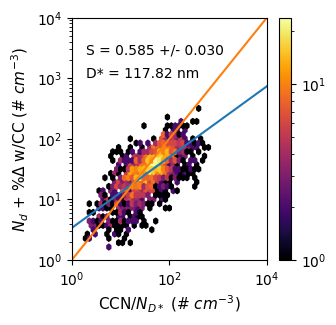

In [72]:
plt.figure(figsize = (8*cm,8*cm))
x =NorESM_ds['Tot_dis'].isel(lev = z).where(NorESM_ds['D']>NorDiameterUp1CC).sum('D')*dx[0].where(NorESM_ds['DropletsCCUp1'].isel(lev = z)>0).dropna('time')
y = NorESM_ds['DropletsCCUp1'].isel(lev = z).dropna('time')
Sus = Susceptibility(x,y)
plt.text(2,2500,f'S = {Sus[0]:.3f} +/- {Sus[1]*1.98:.3f}', fontsize = 10)
plt.text(2,1000,f'D* = {NorDiameterUp1CC[0]:.2f} nm', fontsize = 10)
plt.xlabel('CCN/$N_{D*}$ (# $cm^{-3}$)',fontsize = 11)
plt.ylabel(r'$N_d$ + %$\Delta$ w/CC (# $cm^{-3}$)', fontsize = 11)

NdtoCCNGraph(x,y)

In [73]:
ECSusUp1 = []
ECSusUp2 = []
ECSusUp3 = []
ECSusUp1CC = []
ECSusUp2CC = []
ECSusUp3CC = []
ListECSus_ = [ECSusUp1,ECSusUp2,ECSusUp3,ECSusUp1CC,ECSusUp2CC,ECSusUp3CC]
for cluster in range(6):
    for i in range(3):
        print(cluster*i+i)
        for z in range(10):
            ListECSus_[i].append(Susceptibility(ECGroup[cluster]['Tot_dis'].isel(lev = z).where(ECGroup[cluster]['D']>ECActR[cluster*i+i]).sum('D')*dx[0].where(ECGroup[cluster]['Droplets'].isel(lev = z)>0).dropna('time'),ECGroup[cluster]['Droplets'].isel(lev = z).dropna('time')))
            if i == 0:
                if cluster == 0:
                    ListECSus_[i+3].append(np.nan)
                    continue
                ListECSus_[i+3].append(Susceptibility(ECGroup[cluster]['Tot_dis'].isel(lev = z).where(ECGroup[cluster]['D']>ECActR_CC[cluster*i+i]).sum('D')*dx[0].where(ECGroup[cluster]['DropletsCCUp1'].isel(lev = z)>0).dropna('time'),ECGroup[cluster]['DropletsCCUp1'].isel(lev = z).dropna('time')))
            if i == 1:
                if cluster == 0:
                    ListECSus_[i+3].append(np.nan)
                    continue                
                ListECSus_[i+3].append(Susceptibility(ECGroup[cluster]['Tot_dis'].isel(lev = z).where(ECGroup[cluster]['D']>ECActR_CC[cluster*i+i]).sum('D')*dx[0].where(ECGroup[cluster]['DropletsCCUp2'].isel(lev = z)>0).dropna('time'),ECGroup[cluster]['DropletsCCUp2'].isel(lev = z).dropna('time')))
            if i == 2:
                if cluster == 0:
                    ListECSus_[i+3].append(np.nan)
                    continue
                ListECSus_[i+3].append(Susceptibility(ECGroup[cluster]['Tot_dis'].isel(lev = z).where(ECGroup[cluster]['D']>ECActR_CC[cluster*i+i]).sum('D')*dx[0].where(ECGroup[cluster]['DropletsCCUp3'].isel(lev = z)>0).dropna('time'),ECGroup[cluster]['DropletsCCUp3'].isel(lev = z).dropna('time')))

0
1
2
0


/tmp/ipykernel_1651907/1662990800.py:23: RuntimeWarning: divide by zero encountered in log10
  X = np.log10(x)
/home/pech2273/.local/lib/python3.12/site-packages/numpy/_core/_methods.py:236: RuntimeWarning: invalid value encountered in subtract
  return um.subtract(


MissingDataError: exog contains inf or nans

In [74]:
ECActR_CC

[nan,
 np.float64(190.56312424898383),
 np.float64(127.02740777196964),
 np.float64(240.99913346981475),
 np.float64(285.87770907458366),
 np.float64(127.02740777196964),
 np.float64(207.54929878718698),
 np.float64(102.61040941702),
 np.float64(72.92254148679628),
 np.float64(141.33523429255584),
 np.float64(186.53840665982455),
 np.float64(77.74520280028237),
 np.float64(144.38465673381506),
 np.float64(74.49590453102621),
 np.float64(57.66139958192239),
 np.float64(98.3218898207321),
 np.float64(132.5679799526813),
 np.float64(64.15613419567872)]

In [75]:
Susceptibility(ECGroup[cluster]['Tot_dis'].isel(lev = z).where(ECGroup[cluster]['D']>ECActR_CC[cluster*i+i]).sum('D')*dx[0].where(ECGroup[cluster]['DropletsCCUp2'].isel(lev = z)>0).dropna('time'),ECGroup[cluster]['DropletsCCUp2'].isel(lev = z).dropna('time'))

/tmp/ipykernel_1651907/1662990800.py:23: RuntimeWarning: divide by zero encountered in log10
  X = np.log10(x)
/home/pech2273/.local/lib/python3.12/site-packages/numpy/_core/_methods.py:236: RuntimeWarning: invalid value encountered in subtract
  return um.subtract(


MissingDataError: exog contains inf or nans

In [76]:
cluster

1

In [77]:
i

0

In [78]:
z

0

In [79]:
ECGroup[cluster]['Tot_dis'].isel(lev = z).where(ECGroup[cluster]['D']>ECActR_CC[cluster*i+i]).sum('D')*dx[0].where(ECGroup[cluster]['DropletsCCUp2'].isel(lev = z)>0).dropna('time')

<xarray.DataArray (time: 2403)> Size: 19kB
array([0., 0., 0., ..., 0., 0., 0.], shape=(2403,))
Coordinates:
  * time       (time) datetime64[ns] 19kB 2012-01-03T15:00:00 ... 2018-12-29T...
    lev        float32 4B 998.9
    station    <U6 24B 'SMR-II'
    time_orig  (time) datetime64[ns] 19kB 2012-01-03T15:30:00 ... 2018-12-29T...
    Dx         float64 8B 0.03765
    index      <U19 76B 'Cluster 2 Updraft 1'
    D          float64 8B 0.3162

In [80]:
print((ECGroup[cluster]['DropletsCCUp2'].isel(lev = z)>0).values)

[False  True False ... False False False]


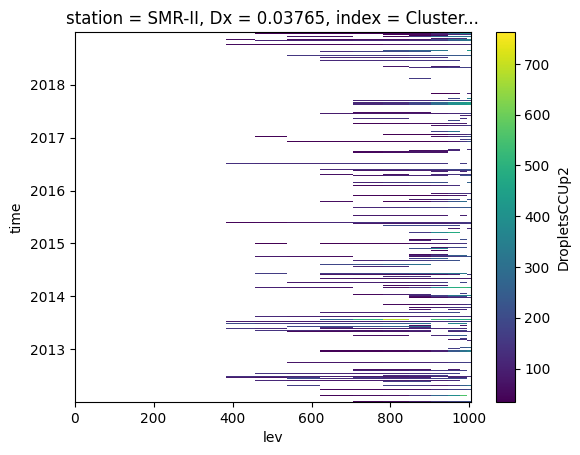

In [81]:
ECGroup[cluster]['DropletsCCUp2'].plot()

In [82]:
ECGroup[cluster]['Tot_dis'].isel(lev = z).where(ECGroup[cluster]['D']>ECActR_CC[cluster*i+i]).sum('D')*dx[0].where(ECGroup[cluster]['DropletsCCUp1'].isel(lev = z)>0).dropna('time')

<xarray.DataArray (time: 2403)> Size: 19kB
array([0., 0., 0., ..., 0., 0., 0.], shape=(2403,))
Coordinates:
  * time       (time) datetime64[ns] 19kB 2012-01-03T15:00:00 ... 2018-12-29T...
    lev        float32 4B 998.9
    station    <U6 24B 'SMR-II'
    time_orig  (time) datetime64[ns] 19kB 2012-01-03T15:30:00 ... 2018-12-29T...
    Dx         float64 8B 0.03765
    index      <U19 76B 'Cluster 2 Updraft 1'
    D          float64 8B 0.3162

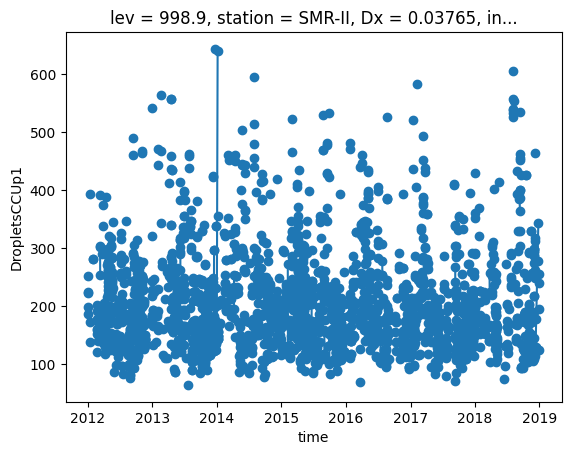

In [83]:
ECGroup[cluster]['DropletsCCUp1'].isel(lev = 0).plot(marker = 'o')

In [84]:
ECGroup[cluster]['D']>ECActR_CC[cluster*i+i]).sum('D')*dx[0]

SyntaxError: unmatched ')' (1711997664.py, line 1)

In [85]:
cluster0 = []
cluster1 = []
cluster2 = []
cluster3 = []
cluster4 = []
cluster5 = []
cluster0_1 = []
cluster1_1 = []
cluster2_1 = []
cluster3_1 = []
cluster4_1 = []
cluster5_1 = []
cluster0_2 = []
cluster1_2 = []
cluster2_2 = []
cluster3_2 = []
cluster4_2 = []
cluster5_2 = []
ECSusUp1 = [cluster0,cluster1,cluster2, cluster3,cluster4,cluster5]
ECSusUp2 = [cluster0_1,cluster1_1,cluster2_1, cluster3_1,cluster4_1,cluster5_1]
ECSusUp3 = [cluster0_2,cluster1_2,cluster2_2, cluster3_2,cluster4_2,cluster5_2]

ListECSus_ = [ECSusUp1,ECSusUp2,ECSusUp3]
cluster = 0
for cluster in range(6):
    for updraft in range(3):
        if updraft == 0:
            UpdraftList = ECSusUp1
        if updraft == 1:
            UpdraftList = ECSusUp2
        if updraft == 2:
            UpdraftList = ECSusUp3
        for z in range(10):
            index = cluster * 30 + updraft * 10 + z
            print(f"Index: {index}, cluster: {cluster}, i: {updraft}, z: {z}")
            UpdraftList[cluster].append(
                Susceptibility(
                    ECGroup[cluster]['Tot_dis'].isel(lev=z)
                    .where(ECGroup[cluster]['D'] > ECActR_df.iloc[updraft, cluster])
                    .sum('D') * dx[0]
                    .where(ECGroup[cluster]['Droplets'].isel(lev=z) > 0)
                    .dropna('time'),
                    ECGroup[cluster]['Droplets'].isel(lev=z).dropna('time')
                )
            )


Index: 0, cluster: 0, i: 0, z: 0
Index: 1, cluster: 0, i: 0, z: 1
Index: 2, cluster: 0, i: 0, z: 2
Index: 3, cluster: 0, i: 0, z: 3
Index: 4, cluster: 0, i: 0, z: 4
Index: 5, cluster: 0, i: 0, z: 5
Index: 6, cluster: 0, i: 0, z: 6
Index: 7, cluster: 0, i: 0, z: 7
Index: 8, cluster: 0, i: 0, z: 8
Index: 9, cluster: 0, i: 0, z: 9
Index: 10, cluster: 0, i: 1, z: 0
Index: 11, cluster: 0, i: 1, z: 1
Index: 12, cluster: 0, i: 1, z: 2
Index: 13, cluster: 0, i: 1, z: 3
Index: 14, cluster: 0, i: 1, z: 4
Index: 15, cluster: 0, i: 1, z: 5
Index: 16, cluster: 0, i: 1, z: 6
Index: 17, cluster: 0, i: 1, z: 7
Index: 18, cluster: 0, i: 1, z: 8
Index: 19, cluster: 0, i: 1, z: 9
Index: 20, cluster: 0, i: 2, z: 0
Index: 21, cluster: 0, i: 2, z: 1
Index: 22, cluster: 0, i: 2, z: 2
Index: 23, cluster: 0, i: 2, z: 3
Index: 24, cluster: 0, i: 2, z: 4
Index: 25, cluster: 0, i: 2, z: 5
Index: 26, cluster: 0, i: 2, z: 6
Index: 27, cluster: 0, i: 2, z: 7
Index: 28, cluster: 0, i: 2, z: 8
Index: 29, cluster: 0, i

In [86]:
cluster0CC = []
cluster1CC = []
cluster2CC = []
cluster3CC = []
cluster4CC = []
cluster5CC = []
cluster0_1CC = []
cluster1_1CC = []
cluster2_1CC = []
cluster3_1CC = []
cluster4_1CC = []
cluster5_1CC = []
cluster0_2CC = []
cluster1_2CC = []
cluster2_2CC = []
cluster3_2CC = []
cluster4_2CC = []
cluster5_2CC = []
ECSusUp1CC = [cluster0CC,cluster1CC,cluster2CC, cluster3CC,cluster4CC,cluster5CC]
ECSusUp2CC = [cluster0_1CC,cluster1_1CC,cluster2_1CC, cluster3_1CC,cluster4_1CC,cluster5_1CC]
ECSusUp3CC = [cluster0_2CC,cluster1_2CC,cluster2_2CC, cluster3_2CC,cluster4_2CC,cluster5_2CC]

ListECSus_CC = [ECSusUp1CC,ECSusUp2CC,ECSusUp3CC]
cluster = 0
for cluster in range(1,6):
    for updraft in range(3):
        if updraft == 0:
            UpdraftList = ECSusUp1CC
            Droplets = 'DropletsCCUp1'
        if updraft == 1:
            UpdraftList = ECSusUp2CC
            Droplets = 'DropletsCCUp2'
        if updraft == 2:
            UpdraftList = ECSusUp3CC
            Droplets = 'DropletsCCUp3'
        for z in range(10):
            index = cluster * 30 + updraft * 10 + z
            print(f"Index: {index}, cluster: {cluster}, i: {updraft}, z: {z}")
            UpdraftList[cluster].append(
                Susceptibility(
                    ECGroup[cluster]['Tot_dis'].isel(lev=z)
                    .where(ECGroup[cluster]['D'] > ECActR_CC_df.iloc[updraft, cluster])
                    .sum('D') * dx[0]
                    .where(ECGroup[cluster][Droplets].isel(lev=z) > 0)
                    .dropna('time'),
                    ECGroup[cluster][Droplets].isel(lev=z).dropna('time')
                )
            )


Index: 30, cluster: 1, i: 0, z: 0
Index: 31, cluster: 1, i: 0, z: 1
Index: 32, cluster: 1, i: 0, z: 2
Index: 33, cluster: 1, i: 0, z: 3
Index: 34, cluster: 1, i: 0, z: 4
Index: 35, cluster: 1, i: 0, z: 5
Index: 36, cluster: 1, i: 0, z: 6
Index: 37, cluster: 1, i: 0, z: 7
Index: 38, cluster: 1, i: 0, z: 8
Index: 39, cluster: 1, i: 0, z: 9
Index: 40, cluster: 1, i: 1, z: 0
Index: 41, cluster: 1, i: 1, z: 1
Index: 42, cluster: 1, i: 1, z: 2
Index: 43, cluster: 1, i: 1, z: 3
Index: 44, cluster: 1, i: 1, z: 4
Index: 45, cluster: 1, i: 1, z: 5
Index: 46, cluster: 1, i: 1, z: 6
Index: 47, cluster: 1, i: 1, z: 7
Index: 48, cluster: 1, i: 1, z: 8
Index: 49, cluster: 1, i: 1, z: 9
Index: 50, cluster: 1, i: 2, z: 0
Index: 51, cluster: 1, i: 2, z: 1
Index: 52, cluster: 1, i: 2, z: 2
Index: 53, cluster: 1, i: 2, z: 3
Index: 54, cluster: 1, i: 2, z: 4
Index: 55, cluster: 1, i: 2, z: 5
Index: 56, cluster: 1, i: 2, z: 6
Index: 57, cluster: 1, i: 2, z: 7
Index: 58, cluster: 1, i: 2, z: 8
Index: 59, clu

In [87]:
len(ListECSus_CC)

3

In [88]:
(ListECSus_[2])

[[(np.float64(0.9889247807275131), np.float64(0.05458430880407267)),
  (np.float64(0.8087525673689344), np.float64(0.02198214255679554)),
  (np.float64(0.7051881307541447), np.float64(0.018577805195648844)),
  (np.float64(0.7590409288354263), np.float64(0.017758107444711627)),
  (np.float64(0.6516834856010902), np.float64(0.028530256183428172)),
  (np.float64(0.5561155528830959), np.float64(0.03077096969063048)),
  (np.float64(0.5941396586721891), np.float64(0.030599767960710688)),
  (np.float64(0.5224380985093239), np.float64(0.043539516003412514)),
  (np.float64(0.4948398371330768), np.float64(0.08113585911873139)),
  (np.float64(0.36395455873145516), np.float64(0.11545239710684083))],
 [(np.float64(0.5845792920552458), np.float64(0.03310569158796368)),
  (np.float64(0.9437277252528035), np.float64(0.021724742560277274)),
  (np.float64(0.8999724103865169), np.float64(0.013936390385740868)),
  (np.float64(0.7557491385403762), np.float64(0.009929926883359795)),
  (np.float64(0.69054704

In [89]:
LevelSus = []
levelEC = []
for z in range(11):
    print(len(ECearth_ds['Droplets'].isel(lev = z).dropna('time')))
    #if len(ECearth_ds['Droplets'].isel(lev = z).dropna('time')) 
    LevelSus.append(Susceptibility(ECearth_ds['TotN70'].isel(lev = z).where(ECearth_ds['Droplets'].isel(lev = z)>0).dropna('time')/1E6,ECearth_ds['Droplets'].isel(lev = z).dropna('time')))
    levelEC.append(ECearth_ds['lev'].isel(lev = z))

7095
11509
12661
13082
12537
10971
8697
6540
4590
3162
1442


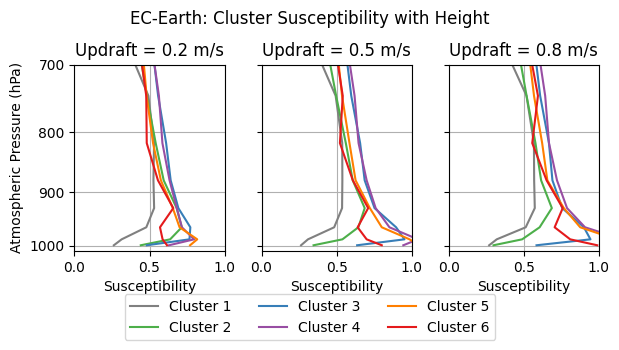

In [90]:
# Setup
fig, axes = plt.subplots(1, 3, figsize=(16 * cm, 8 * cm), sharey=True)
colors = ['#e41a1c','#377eb8','#4daf4a','#984ea3','#ff7f00','grey']
labelNoCC = ['Cluster 6', 'Cluster 3', 'Cluster 2', 'Cluster 4', 'Cluster 5', 'Cluster 1']
order = [5, 2, 1, 3, 4, 0]  # plotting order
updrafts = [0.2, 0.5, 0.8]

# Create a mapping from cluster label to color
label_color_map = dict(zip(labelNoCC, colors))
sorted_labels = sorted(labelNoCC, key=lambda x: int(x.split()[-1]))  # Cluster 1 -> Cluster 6

# Plotting loop
handles_for_legend = {label: None for label in sorted_labels}  # placeholder

for idx, ax in enumerate(axes):
    for i in order:
        label = labelNoCC[i]
        listofSus = [ListECSus_[idx][i][z][0] for z in range(10)]
        line, = ax.plot(listofSus, levelEC[0:10], color=label_color_map[label], linestyle='-')
        if idx == 0 and handles_for_legend[label] is None:
            handles_for_legend[label] = line

    ax.set_title(f'Updraft = {updrafts[idx]} m/s')
    ax.set_xlabel('Susceptibility')
    ax.set_xlim(0, 1)
    ax.set_ylim(1010, 700)
    ax.set_yscale('log')
    ax.set_yticks([700, 800, 900, 1000])
    ax.set_yticklabels([700, 800, 900, 1000])
    ax.grid()

# Shared y-axis label
axes[0].set_ylabel('Atmospheric Pressure (hPa)')

# Ordered legend
fig.legend(
    [handles_for_legend[label] for label in sorted_labels],
    sorted_labels,
    loc='lower center',
    bbox_to_anchor=(0.5, -0.12),
    ncol=3
)

plt.tight_layout(rect=[0, 0.05, 1, 1])  # leave space for bottom legend
# Shared legend on the side
plt.suptitle('EC-Earth: Cluster Susceptibility with Height', y = .95)
plt.tight_layout()
plt.show()

/tmp/ipykernel_1651907/2000110190.py:36: UserWarning: Legend does not support handles for NoneType instances.
A proxy artist may be used instead.
See: https://matplotlib.org/stable/users/explain/axes/legend_guide.html#controlling-the-legend-entries
  fig.legend(


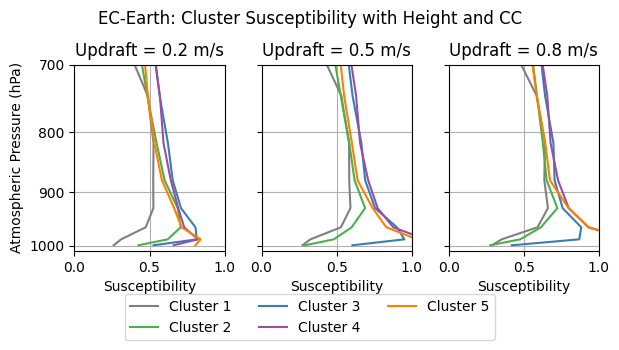

In [91]:
# Setup
fig, axes = plt.subplots(1, 3, figsize=(16 * cm, 8 * cm), sharey=True)
colors = ['#e41a1c','#377eb8','#4daf4a','#984ea3','#ff7f00','grey']
labelNoCC = ['Cluster 6','Cluster 3', 'Cluster 2', 'Cluster 4', 'Cluster 5', 'Cluster 1']
order = [5, 2, 1, 3, 4, 0]  # plotting order
updrafts = [0.2, 0.5, 0.8]

# Create a mapping from cluster label to color
label_color_map = dict(zip(labelNoCC, colors))
sorted_labels = sorted(labelNoCC, key=lambda x: int(x.split()[-1]))  # Cluster 1 -> Cluster 6

# Plotting loop
handles_for_legend = {label: None for label in sorted_labels}  # placeholder

for idx, ax in enumerate(axes):
    for i in order[0:5]:
        label = labelNoCC[i]
        listofSus = [ListECSus_CC[idx][i][z][0] for z in range(10)]
        line, = ax.plot(listofSus, levelEC[0:10], color=label_color_map[label], linestyle='-')
        if idx == 0 and handles_for_legend[label] is None:
            handles_for_legend[label] = line

    ax.set_title(f'Updraft = {updrafts[idx]} m/s')
    ax.set_xlabel('Susceptibility')
    ax.set_xlim(0, 1)
    ax.set_ylim(1010, 700)
    ax.set_yscale('log')
    ax.set_yticks([700, 800, 900, 1000])
    ax.set_yticklabels([700, 800, 900, 1000])
    ax.grid()

# Shared y-axis label
axes[0].set_ylabel('Atmospheric Pressure (hPa)')

# Ordered legend
fig.legend(
    [handles_for_legend[label] for label in sorted_labels],
    sorted_labels,
    loc='lower center',
    bbox_to_anchor=(0.5, -0.12),
    ncol=3
)

plt.tight_layout(rect=[0, 0.05, 1, 1])  # leave space for bottom legend
# Shared legend on the side
plt.suptitle('EC-Earth: Cluster Susceptibility with Height and CC', y = .95)
plt.tight_layout()
plt.show()

/tmp/ipykernel_1651907/1684829221.py:36: UserWarning: Legend does not support handles for NoneType instances.
A proxy artist may be used instead.
See: https://matplotlib.org/stable/users/explain/axes/legend_guide.html#controlling-the-legend-entries
  fig.legend(


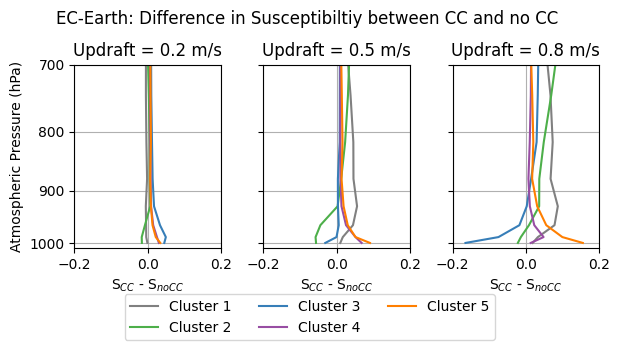

In [92]:
# Setup
fig, axes = plt.subplots(1, 3, figsize=(16 * cm, 8 * cm), sharey=True)
colors = ['#e41a1c','#377eb8','#4daf4a','#984ea3','#ff7f00','grey']
labelNoCC = ['Cluster 6','Cluster 3', 'Cluster 2', 'Cluster 4', 'Cluster 5', 'Cluster 1']
order = [5, 2, 1, 3, 4, 0]  # plotting order
updrafts = [0.2, 0.5, 0.8]

# Create a mapping from cluster label to color
label_color_map = dict(zip(labelNoCC, colors))
sorted_labels = sorted(labelNoCC, key=lambda x: int(x.split()[-1]))  # Cluster 1 -> Cluster 6

# Plotting loop
handles_for_legend = {label: None for label in sorted_labels}  # placeholder

for idx, ax in enumerate(axes):
    for i in order[0:5]:
        label = labelNoCC[i]
        listofSus = [ListECSus_CC[idx][i][z][0]-ListECSus_[idx][i][z][0] for z in range(10)]
        line, = ax.plot(listofSus, levelEC[0:10], color=label_color_map[label], linestyle='-')
        if idx == 0 and handles_for_legend[label] is None:
            handles_for_legend[label] = line

    ax.set_title(f'Updraft = {updrafts[idx]} m/s')
    ax.set_xlabel('S$_{CC}$ - S$_{no CC}$')
    ax.set_xlim(-.2, .2)
    ax.set_ylim(1010, 700)
    ax.set_yscale('log')
    ax.set_yticks([700, 800, 900, 1000])
    ax.set_yticklabels([700, 800, 900, 1000])
    ax.grid()

# Shared y-axis label
axes[0].set_ylabel('Atmospheric Pressure (hPa)')

# Ordered legend
fig.legend(
    [handles_for_legend[label] for label in sorted_labels],
    sorted_labels,
    loc='lower center',
    bbox_to_anchor=(0.5, -0.12),
    ncol=3
)

plt.tight_layout(rect=[0, 0.05, 1, 1])  # leave space for bottom legend
# Shared legend on the side
plt.suptitle('EC-Earth: Difference in Susceptibiltiy between CC and no CC ', y = .95)
plt.tight_layout()
plt.show()

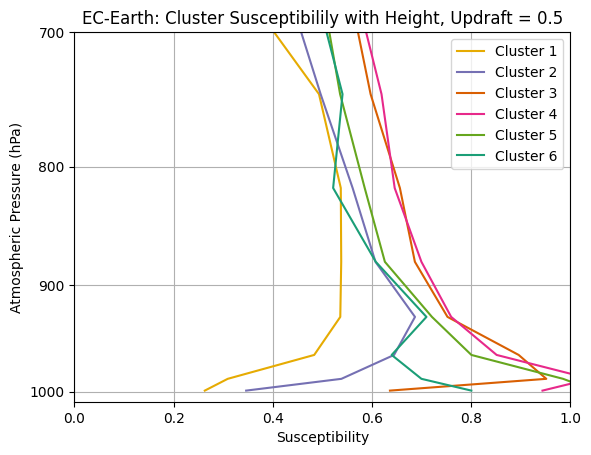

In [93]:
colors = ['#1b9e77','#d95f02','#7570b3','#e7298a','#66a61e','#e6ab02']
labelNoCC = ['Cluster 6', 'Cluster 3', 'Cluster 2', 'Cluster 4', 'Cluster 5', 'Cluster 1']
order = [5,2,1,3,4,0]

for i in order:
    listofSus = []    
    for z in range(10):
        listofSus.append(ListECSus_[1][i][z][0])
    plt.plot(listofSus,levelEC[0:10],color = colors[i], linestyle = '-', label = labelNoCC[i])


plt.legend()       
plt.ylim(1010,700)
plt.title('EC-Earth: Cluster Susceptibilily with Height, Updraft = 0.5')
plt.ylabel('Atmospheric Pressure (hPa)')
plt.xlabel('Susceptibility')
plt.xlim(0,1)
plt.grid()
plt.yscale('log')
plt.yticks([700,800,900,1000],[700,800,900,1000])
plt.show()


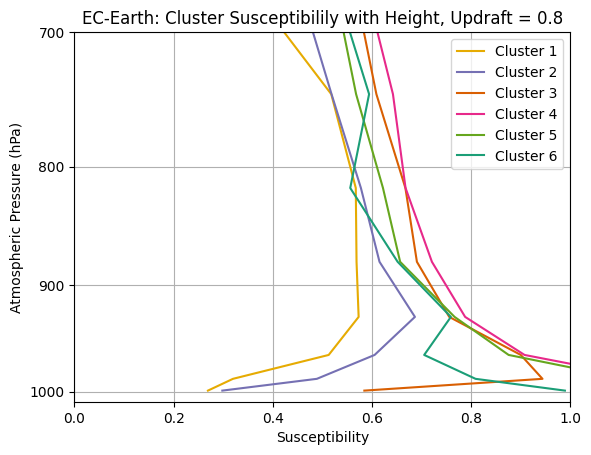

In [94]:
colors =['#1b9e77','#d95f02','#7570b3','#e7298a','#66a61e','#e6ab02']
labelNoCC = ['Cluster 6', 'Cluster 3', 'Cluster 2', 'Cluster 4', 'Cluster 5', 'Cluster 1']
order = [5,2,1,3,4,0]

for i in order:
    listofSus = []    
    for z in range(10):
        listofSus.append(ListECSus_[2][i][z][0])
    plt.plot(listofSus,levelEC[0:10],color = colors[i], linestyle = '-', label = labelNoCC[i])


plt.legend()       
plt.ylim(1010,700)
plt.title('EC-Earth: Cluster Susceptibilily with Height, Updraft = 0.8')
plt.ylabel('Atmospheric Pressure (hPa)')
plt.xlabel('Susceptibility')
plt.xlim(0,1)
plt.grid()
plt.yscale('log')
plt.yticks([700,800,900,1000],[700,800,900,1000])
plt.show()

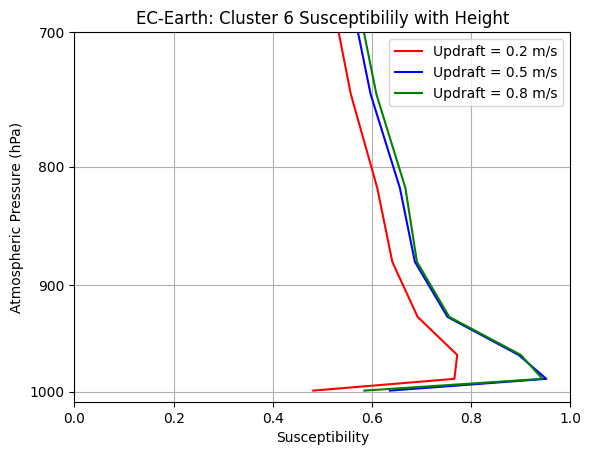

In [95]:
colors =['red','blue','green']
labelNoCC = ['Updraft = 0.2 m/s','Updraft = 0.5 m/s','Updraft = 0.8 m/s']

for i in range(3):

    color_ = colors[i%3]
    listofSus = []
    
    for z in range(10):
        listofSus.append(ListECSus_[i][1][z][0])
    if i <= 2:
        plt.plot(listofSus,levelEC[0:10],color = color_, linestyle = '-', label = labelNoCC[i])


plt.legend()       
plt.ylim(1010,700)
plt.title('EC-Earth: Cluster 6 Susceptibilily with Height')
plt.ylabel('Atmospheric Pressure (hPa)')
plt.xlabel('Susceptibility')
plt.xlim(0,1)
plt.grid()
plt.yscale('log')
plt.yticks([700,800,900,1000],[700,800,900,1000])
plt.show()

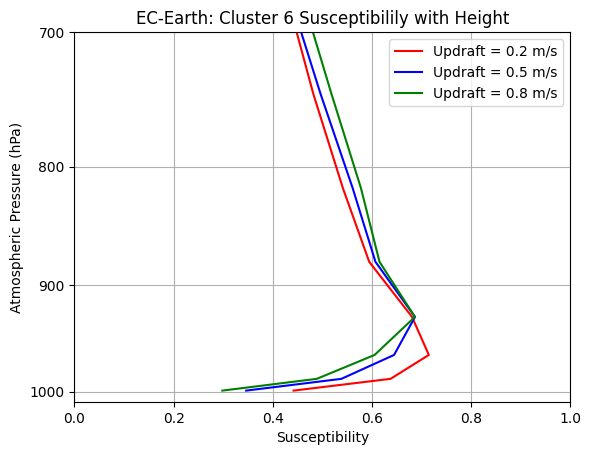

In [96]:
colors =['red','blue','green']
labelNoCC = ['Updraft = 0.2 m/s','Updraft = 0.5 m/s','Updraft = 0.8 m/s']

for i in range(3):

    color_ = colors[i%3]
    listofSus = []
    
    for z in range(10):
        listofSus.append(ListECSus_[i][2][z][0])
    if i <= 2:
        plt.plot(listofSus,levelEC[0:10],color = color_, linestyle = '-', label = labelNoCC[i])


plt.legend()       
plt.ylim(1010,700)
plt.title('EC-Earth: Cluster 6 Susceptibilily with Height')
plt.ylabel('Atmospheric Pressure (hPa)')
plt.xlabel('Susceptibility')
plt.xlim(0,1)
plt.grid()
plt.yscale('log')
plt.yticks([700,800,900,1000],[700,800,900,1000])
plt.show()

IndexError: list index out of range

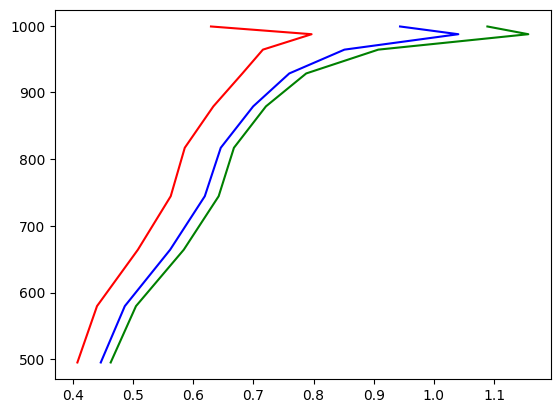

In [97]:
colors =['red','blue','green']
labelNoCC = ['Updraft = 0.2 m/s','Updraft = 0.5 m/s','Updraft = 0.8 m/s']

for i in range(6):

    color_ = colors[i%3]
    listofSus = []
    
    for z in range(10):
        listofSus.append(ListECSus_[i][3][z][0])
    if i <= 2:
        plt.plot(listofSus,levelEC[0:10],color = color_, linestyle = '-', label = labelNoCC[i])


plt.legend()       
plt.ylim(1010,700)
plt.title('EC-Earth: Cluster 6 Susceptibilily with Height')
plt.ylabel('Atmospheric Pressure (hPa)')
plt.xlabel('Susceptibility')
plt.xlim(0,1)
plt.grid()
plt.yscale('log')
plt.yticks([700,800,900,1000],[700,800,900,1000])
plt.show()

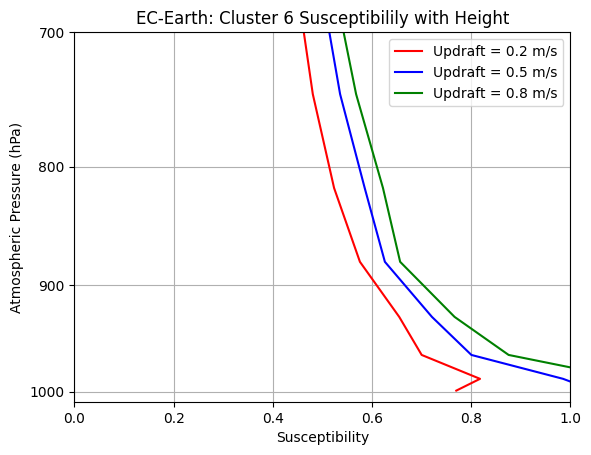

In [98]:
colors =['red','blue','green']
labelNoCC = ['Updraft = 0.2 m/s','Updraft = 0.5 m/s','Updraft = 0.8 m/s']

for i in range(3):

    color_ = colors[i%3]
    listofSus = []
    
    for z in range(10):
        listofSus.append(ListECSus_[i][4][z][0])
    if i <= 2:
        plt.plot(listofSus,levelEC[0:10],color = color_, linestyle = '-', label = labelNoCC[i])


plt.legend()       
plt.ylim(1010,700)
plt.title('EC-Earth: Cluster 6 Susceptibilily with Height')
plt.ylabel('Atmospheric Pressure (hPa)')
plt.xlabel('Susceptibility')
plt.xlim(0,1)
plt.grid()
plt.yscale('log')
plt.yticks([700,800,900,1000],[700,800,900,1000])
plt.show()

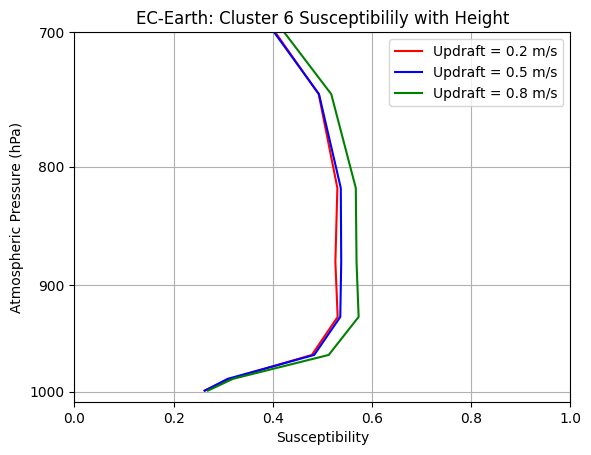

In [99]:
colors =['red','blue','green']
labelNoCC = ['Updraft = 0.2 m/s','Updraft = 0.5 m/s','Updraft = 0.8 m/s']

for i in range(3):

    color_ = colors[i%3]
    listofSus = []
    
    for z in range(10):
        listofSus.append(ListECSus_[i][5][z][0])
    if i <= 2:
        plt.plot(listofSus,levelEC[0:10],color = color_, linestyle = '-', label = labelNoCC[i])


plt.legend()       
plt.ylim(1010,700)
plt.title('EC-Earth: Cluster 6 Susceptibilily with Height')
plt.ylabel('Atmospheric Pressure (hPa)')
plt.xlabel('Susceptibility')
plt.xlim(0,1)
plt.grid()
plt.yscale('log')
plt.yticks([700,800,900,1000],[700,800,900,1000])
plt.show()

In [100]:
for i in order:
    print((ECMassFracGroups[i]['OAMassFrac'].isel(lev = 0).median()*100).values)

52.93670892715454
46.24454975128174
54.72208261489868
62.33478784561157
65.85131883621216
67.40869879722595


In [101]:
NorClusters = [3,1,0,2]
for i in NorClusters:
    print((NorMassFracGroups[i]['OAMassFrac'].isel(lev = -1).median()*100).values)

28.656694293022156
38.879403471946716
51.49378776550293
62.83830404281616


In [102]:
ECMassFracGroups[0]['OAMassFrac']

<xarray.DataArray 'OAMassFrac' (time: 2009, lev: 34)> Size: 273kB
[68306 values with dtype=float32]
Coordinates:
  * lev        (lev) float32 136B 9.989e+04 9.873e+04 9.642e+04 ... 48.77 10.71
  * time       (time) datetime64[ns] 16kB 2012-01-08T19:00:00 ... 2018-12-25
    station    <U6 24B ...
    time_orig  (time) datetime64[ns] 16kB ...

In [103]:
NorESM_ds['lev']

<xarray.DataArray 'lev' (lev: 32)> Size: 256B
array([  3.643466,   7.59482 ,  14.356632,  24.61222 ,  35.92325 ,  43.19375 ,
        51.677499,  61.520498,  73.750958,  87.82123 , 103.317127, 121.547241,
       142.994039, 168.22508 , 197.908087, 232.828619, 273.910817, 322.241902,
       379.100904, 445.992574, 524.687175, 609.778695, 691.38943 , 763.404481,
       820.858369, 859.534767, 887.020249, 912.644547, 936.198398, 957.48548 ,
       976.325407, 992.556095])
Coordinates:
    station  <U6 24B ...
  * lev      (lev) float64 256B 3.643 7.595 14.36 24.61 ... 957.5 976.3 992.6
    Dx       float64 8B ...
    index    <U19 76B ...